# FashionMNIST 分类 —— 使用 PyTorch CNN 卷积神经网络（卷积神经网络CNN1.md）

本脚本实现了 FashionMNIST 数据集的 10 分类任务（CNN 版本），包括：
1. 数据加载与预处理
2. 数据可视化
3. 训练集均值/标准差计算与标准化
4. 卷积神经网络（CNN）模型构建（ReLU 激活）
5. 模型参数统计
6. Trainer 通用训练器类（含早停、TensorBoard、绘图）
7. 模型训练与验证（ReLU 版 CNN）
8. 测试集评估（ReLU 版 CNN）
9. SELU 版 CNN 模型构建（自归一化激活函数）
10. SELU 模型训练与评估
11. 深度可分离卷积 (Depthwise Separable Convolution) 模块定义
12. 深度可分离卷积版 CNN 模型构建与参数统计
13. 深度可分离卷积版模型训练与评估
14. ReLU vs SELU vs Separable-CNN 三模型对比总结

In [1]:
import torch  # PyTorch 核心库，提供张量运算与自动求导
import torch.nn as nn  # 神经网络模块，提供 Conv2d、Linear、ReLU 等层
import torch.optim as optim  # 优化器模块，提供 SGD、Adam 等
from torchvision import datasets, transforms  # 提供常用数据集与数据预处理变换
import matplotlib.pyplot as plt  # 绘图库，用于数据可视化与训练曲线绘制
import os  # 操作系统接口，用于创建目录、判断文件是否存在等
from torch.utils.tensorboard import SummaryWriter  # TensorBoard 写入器，用于记录训练日志

## 1. 数据加载与预处理

In [2]:
# 定义数据预处理流程
# transforms.Compose: 将多个 transform 操作组合在一起，按顺序执行
# transforms.ToTensor(): 将 PIL.Image (0-255) 转换为 torch.Tensor (0.0-1.0)，并将 H×W×C 变为 C×H×W
transform = transforms.Compose([
    transforms.ToTensor(),  # 将 PIL 图片转为 0.0-1.0 的张量
])

In [3]:
# 下载并加载 FashionMNIST 训练集
# root: 数据存放目录
# train=True: 加载训练集（60,000 张）
# download=False: 不重新下载（若已下载过；首次使用需设为 True）
# transform: 对每张图片施加的预处理操作
full_train_dataset = datasets.FashionMNIST(
    root='./data',  # 数据集存储路径
    train=True,  # True=训练集, False=测试集
    download=False,  # 是否下载数据集（首次需设为 True）
    transform=transform  # 数据预处理变换
)

In [4]:
# 从训练集中分出 5000 张作为验证集
# 总训练样本 60,000 → 训练集 55,000 + 验证集 5,000
train_size = len(full_train_dataset) - 5000  # 训练集大小: 55000
val_size = 5000  # 验证集大小: 5000

In [5]:
# random_split: 将数据集随机打乱后按指定长度切分，避免验证集与训练集分布不同
# generator: 随机数生成器，用于控制切分时的打乱顺序
#   - torch.Generator(): 创建一个新的随机数生成器实例（独立于全局默认生成器，互不干扰）
#   - .manual_seed(42): 手动设置随机种子为 42，使生成的随机序列固定
#     作用: 保证每次运行脚本时，数据集的切分方式完全一致
#           → 训练集/验证集划分结果可复现，便于调试与结果对比
#     若不指定 generator，random_split 会使用全局随机状态，每次运行划分不同，结果难以复现
#   - "42" 是机器学习社区常用的种子值，任意整数均可
generator = torch.Generator().manual_seed(42)  # 创建固定种子的随机数生成器
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset,  # 原始数据集
    [train_size, val_size],  # 切分后各部分长度
    generator=generator  # 传入生成器，使切分结果可复现
)

In [6]:
# DataLoader: 将数据集包装成可迭代的批量加载器
# batch_size=64: 每个 batch 包含 64 张图片
# shuffle=True: 每个 epoch 打乱数据顺序，防止模型记忆样本顺序（验证/测试集不需要）
train_loader = torch.utils.data.DataLoader(
    train_dataset,  # 训练集
    batch_size=64,  # 批量大小，影响训练速度和梯度稳定性
    shuffle=True  # 是否在每个 epoch 打乱数据
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,  # 验证集
    batch_size=64,  # 批量大小
    shuffle=False  # 验证集不需要打乱
)

In [7]:
# 下载并加载 FashionMNIST 测试集（10,000 张）
test_dataset = datasets.FashionMNIST(
    root='./data',  # 数据集存储路径
    train=False,  # False 表示加载测试集
    download=False,  # 是否下载数据集
    transform=transform  # 数据预处理变换
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,  # 测试集
    batch_size=64,  # 批量大小
    shuffle=False  # 测试集不需要打乱
)

In [8]:
# 打印各数据集样本数
print("训练集样本数：", len(train_dataset))  # 55000
print("验证集样本数：", len(val_dataset))  # 5000
print("测试集样本数：", len(test_dataset))  # 10000

训练集样本数： 55000
验证集样本数： 5000
测试集样本数： 10000


In [9]:
# 查看 10 个类别名称
# 0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat
# 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot
class_names = full_train_dataset.classes  # 获取类别名称列表
print("类别名称:", class_names)  # 打印类别名称

类别名称: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 2. 数据可视化

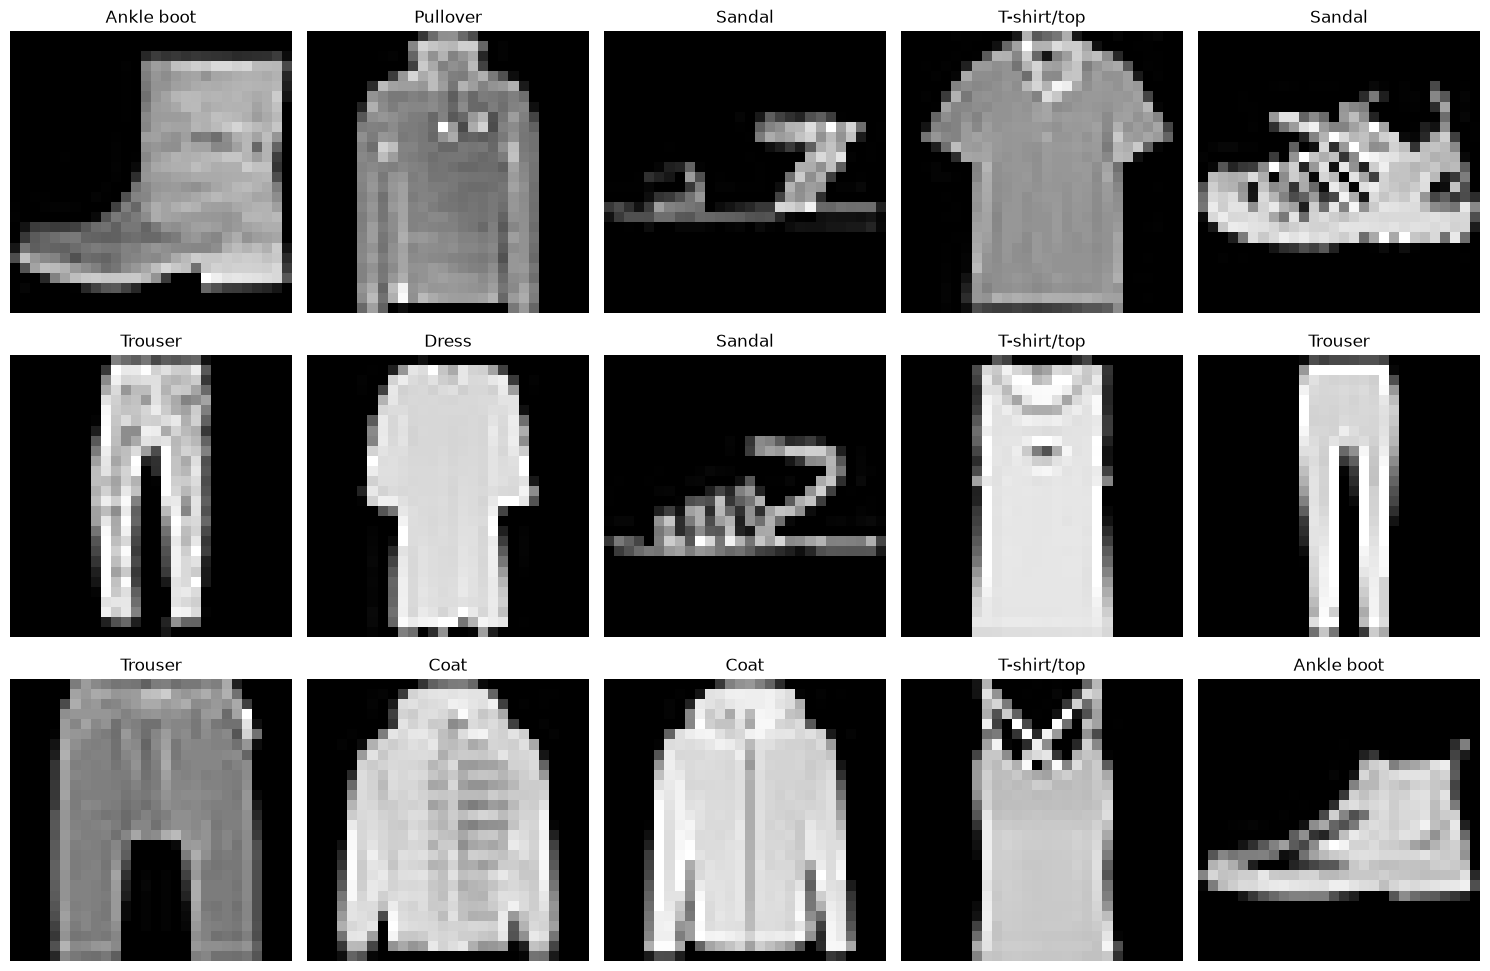

In [10]:
# 可视化训练集前 15 个样本，查看图片内容与对应标签
fig, axs = plt.subplots(3, 5, figsize=(15, 10))  # 创建 3×5 子图，画布大小 15×10 英寸
axs = axs.flatten()  # 将 2D 轴数组展平为 1D，方便索引

for i in range(15):  # 遍历前 15 个样本
    img, label = train_dataset[i]  # img 形状: (1, 28, 28) 即 (C, H, W)，label 是 0-9 的整数
    img = img.squeeze().numpy()  # squeeze() 去掉通道维度 → (28, 28)，再转 numpy
    axs[i].imshow(img, cmap='gray')  # 以灰度图方式显示
    axs[i].set_title(class_names[label])  # 标题为对应的类别名称
    axs[i].axis('off')  # 隐藏坐标轴

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()  # 显示图像

In [11]:
# 查看数据集基本信息
# train_dataset 总共 55000 个样本，每个样本是一个 (image_tensor, label) 元组
print("训练集类型:", type(train_dataset))  # <class 'torch.utils.data.dataset.Subset'>
print("训练集样本总数:", len(train_dataset))  # 55000
print("单张图片的 shape (C, H, W):", train_dataset[0][0].shape)  # torch.Size([1, 28, 28])
print("第一张图片的标签编号:", train_dataset[0][1])  # 某个 0-9 的整数

训练集类型: <class 'torch.utils.data.dataset.Subset'>
训练集样本总数: 55000
单张图片的 shape (C, H, W): torch.Size([1, 28, 28])
第一张图片的标签编号: 9


## 3. 计算训练集的均值和标准差（用于后续标准化 Normalization）
标准化公式: x_norm = (x - mean) / std
计算前需先把所有样本堆叠成一个大 tensor，再按公式求均值与方差。
注意: 这里统计的是 train_dataset（已切分后的 55000 张），而非 full_train_dataset。
      若显存不足，可改用分批累加的方式计算，避免一次性加载全部图片。

In [12]:
# 将 train_dataset 中每张图片取出，组成列表；每个元素 shape 为 (1, 28, 28)
all_imgs = [train_dataset[i][0] for i in range(len(train_dataset))]  # 列表推导式收集所有图片张量

In [13]:
# torch.stack: 沿新维度(第0维)把列表中的张量堆叠起来
# 堆叠后 shape: (样本数 N, 1, 28, 28)
all_imgs = torch.stack(all_imgs)  # 将所有图片堆叠为一个大张量

In [14]:
# view(-1): 将任意 shape 的张量展平为一维（共 N*1*28*28 个像素值）
# -1 表示该维度由系统根据元素总数自动推断
all_imgs_flat = all_imgs.view(-1)  # 展平为一维张量

In [15]:
# 计算所有像素值的均值: mean = (1/n) * Σ xi
mean = all_imgs_flat.mean().item()  # .item() 将标量张量转为 Python float

In [16]:
# 计算 (xi^2) 的均值: mean_of_squares = (1/n) * Σ xi^2
mean_of_squares = (all_imgs_flat ** 2).mean().item()  # 平方后再求均值

In [17]:
# 按方差公式计算: Var = E[X^2] - (E[X])^2 = mean(x^2) - mean(x)^2
# 该公式等价于 Σ(xi - mean)^2 / n，但计算更高效（无需二次遍历）
var = mean_of_squares - mean ** 2  # 方差 = 平方的均值 - 均值的平方

In [18]:
print("Train dataset mean:", mean)  # 训练集像素均值（ToTensor 后约 0.2860）
print("Train dataset variance:", var)  # 训练集像素方差

Train dataset mean: 0.28556570410728455
Train dataset variance: 0.12441743466474176


In [19]:
# 标准差 = 方差的算术平方根
std = var ** 0.5  # 开平方根得到标准差
print("Train dataset std:", std)  # 训练集像素标准差（约 0.3530）

Train dataset std: 0.3527285566334852


### 用计算出的 mean/std 构建带标准化的 transform
transforms.Normalize(mean, std): 对每个通道逐元素做 (x - mean) / std
  - FashionMNIST 为单通道灰度图，故 mean/std 各传一个值，写成单元素元组 (mean,) (std,)
  - 归一化后像素分布变为均值 0、方差 1，输入尺度统一，有助于模型更快收敛
  - 顺序很重要: 必须先 ToTensor()（转为 0-1 浮点）再 Normalize()，不能反

In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 先把 PIL 图片转为 0.0-1.0 的张量
    transforms.Normalize((mean,), (std,))  # 再标准化: x_norm = (x - mean) / std
])

In [21]:
# 将新的 transform 重新挂载到已加载的数据集上
#   - 数据集在 __getitem__ 时才按"当前" self.transform 处理图片，
#     因此无需重新加载数据，直接重新赋值即可让后续迭代生效
#   - train_dataset / val_dataset 是 random_split 产生的 Subset，
#     其 __getitem__ 会委托给底层 full_train_dataset，所以只需修改
#     full_train_dataset.transform，训练集与验证集会同步生效
full_train_dataset.transform = transform  # 训练集与验证集（Subset 共享底层）同步生效
test_dataset.transform = transform  # 测试集也使用相同的标准化参数

In [22]:
print(f"已应用标准化: Normalize(mean={mean:.4f}, std={std:.4f})")  # 打印确认

已应用标准化: Normalize(mean=0.2856, std=0.3527)


## 4. CNN 模型定义（带调试打印版，用于理解数据流动）

In [23]:
class CNNModelDebug(nn.Module):
    """
    CNN 卷积神经网络（带 shape 打印，便于理解各层数据流）
    结构概述:
      输入 (1, 28, 28) 灰度图
      → 第一组: Conv→ReLU→Conv→ReLU→MaxPool (28→14)
      → 第二组: Conv→ReLU→Conv→ReLU→MaxPool (14→7)
      → 第三组: Conv→ReLU→Conv→ReLU→MaxPool (7→3)
      → 展平 → FC(128*3*3, 128) → ReLU → FC(128, 10)
    """

    def __init__(self):
        super().__init__()  # 调用父类 nn.Module 的构造函数
        # ====== 第一组卷积 + 池化 ======
        # nn.Conv2d(输入通道, 输出通道, kernel_size, padding): 二维卷积层
        #   - in_channels=1: FashionMNIST 是单通道灰度图
        #   - out_channels=32: 使用 32 个卷积核，输出 32 个特征图
        #   - kernel_size=3: 3×3 卷积核
        #   - padding=1: 在输入四周各补 1 圈 0，保持空间尺寸不变 (28→28)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # (1,28,28)→(32,28,28)
        self.relu1 = nn.ReLU()  # ReLU 激活函数: f(x)=max(0,x)，引入非线性
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)  # (32,28,28)→(32,28,28)
        self.relu2 = nn.ReLU()  # ReLU 激活
        # nn.MaxPool2d(kernel_size, stride): 最大池化层，下采样缩小特征图
        #   - kernel_size=2: 在 2×2 窗口中取最大值
        #   - stride=2: 滑动步长 2，尺寸减半 (28→14)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # (32,28,28)→(32,14,14)

        # ====== 第二组卷积 + 池化 ======
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (32,14,14)→(64,14,14)
        self.relu3 = nn.ReLU()  # ReLU 激活
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # (64,14,14)→(64,14,14)
        self.relu4 = nn.ReLU()  # ReLU 激活
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # (64,14,14)→(64,7,7)

        # ====== 第三组卷积 + 池化 ======
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # (64,7,7)→(128,7,7)
        self.relu5 = nn.ReLU()  # ReLU 激活
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)  # (128,7,7)→(128,7,7)
        self.relu6 = nn.ReLU()  # ReLU 激活
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # (128,7,7)→(128,3,3)

        # ====== 全连接分类器 ======
        # 展平后输出尺寸: 128 通道 × 3 高度 × 3 宽度 = 1152 维
        self.fc1 = nn.Linear(128 * 3 * 3, 128)  # 全连接层: 1152 → 128
        self.relu_fc = nn.ReLU()  # ReLU 激活
        self.fc2 = nn.Linear(128, 10)  # 输出层: 128 → 10（10 个类别 logits）

    def forward(self, x):
        """前向传播（包含调试打印）"""
        # ====== 第一组 ======
        print("Input shape:", x.shape)  # 例如 (4, 1, 28, 28)
        x = self.conv1(x)  # 卷积 → (4, 32, 28, 28)
        print("After conv1:", x.shape)  # (4, 32, 28, 28)
        x = self.relu1(x)  # ReLU 激活
        print("After relu1:", x.shape)  # (4, 32, 28, 28)
        x = self.conv2(x)  # 卷积 → (4, 32, 28, 28)
        print("After conv2:", x.shape)  # (4, 32, 28, 28)
        x = self.relu2(x)  # ReLU 激活
        print("After relu2:", x.shape)  # (4, 32, 28, 28)
        x = self.pool1(x)  # 最大池化 → (4, 32, 14, 14)
        print("After pool1:", x.shape)  # (4, 32, 14, 14)

        # ====== 第二组 ======
        x = self.conv3(x)  # 卷积 → (4, 64, 14, 14)
        print("After conv3:", x.shape)  # (4, 64, 14, 14)
        x = self.relu3(x)  # ReLU 激活
        print("After relu3:", x.shape)  # (4, 64, 14, 14)
        x = self.conv4(x)  # 卷积 → (4, 64, 14, 14)
        print("After conv4:", x.shape)  # (4, 64, 14, 14)
        x = self.relu4(x)  # ReLU 激活
        print("After relu4:", x.shape)  # (4, 64, 14, 14)
        x = self.pool2(x)  # 最大池化 → (4, 64, 7, 7)
        print("After pool2:", x.shape)  # (4, 64, 7, 7)

        # ====== 第三组 ======
        x = self.conv5(x)  # 卷积 → (4, 128, 7, 7)
        print("After conv5:", x.shape)  # (4, 128, 7, 7)
        x = self.relu5(x)  # ReLU 激活
        print("After relu5:", x.shape)  # (4, 128, 7, 7)
        x = self.conv6(x)  # 卷积 → (4, 128, 7, 7)
        print("After conv6:", x.shape)  # (4, 128, 7, 7)
        x = self.relu6(x)  # ReLU 激活
        print("After relu6:", x.shape)  # (4, 128, 7, 7)
        x = self.pool3(x)  # 最大池化 → (4, 128, 3, 3)
        print("After pool3:", x.shape)  # (4, 128, 3, 3)

        # ====== 展平 + 全连接 ======
        # torch.flatten(x, 1): 从第 1 维开始展平（保留 batch 维不变）
        # (4, 128, 3, 3) → (4, 128*3*3) = (4, 1152)
        x = torch.flatten(x, 1)  # 展平: 保留 batch 维度，后三维展为向量
        print("After flatten:", x.shape)  # (4, 1152)
        x = self.fc1(x)  # 全连接: (4, 1152) → (4, 128)
        print("After fc1:", x.shape)  # (4, 128)
        x = self.relu_fc(x)  # ReLU 激活
        print("After relu_fc:", x.shape)  # (4, 128)
        x = self.fc2(x)  # 输出层: (4, 128) → (4, 10)
        print("After fc2 (output):", x.shape)  # (4, 10)
        return x  # 返回 logits


# 用随机数据测试调试版模型的数据流
# batch_size=4，单通道 28×28 的随机输入
sample_input = torch.randn(4, 1, 28, 28)  # 创建随机输入张量
model_debug = CNNModelDebug()  # 实例化调试版 CNN 模型
output = model_debug(sample_input)  # 前向传播，观察各层 shape 变化
print("前向计算输出 shape:", output.shape)  # torch.Size([4, 10])

Input shape: torch.Size([4, 1, 28, 28])
After conv1: torch.Size([4, 32, 28, 28])
After relu1: torch.Size([4, 32, 28, 28])
After conv2: torch.Size([4, 32, 28, 28])
After relu2: torch.Size([4, 32, 28, 28])
After pool1: torch.Size([4, 32, 14, 14])
After conv3: torch.Size([4, 64, 14, 14])
After relu3: torch.Size([4, 64, 14, 14])
After conv4: torch.Size([4, 64, 14, 14])
After relu4: torch.Size([4, 64, 14, 14])
After pool2: torch.Size([4, 64, 7, 7])
After conv5: torch.Size([4, 128, 7, 7])
After relu5: torch.Size([4, 128, 7, 7])
After conv6: torch.Size([4, 128, 7, 7])
After relu6: torch.Size([4, 128, 7, 7])
After pool3: torch.Size([4, 128, 3, 3])
After flatten: torch.Size([4, 1152])
After fc1: torch.Size([4, 128])
After relu_fc: torch.Size([4, 128])
After fc2 (output): torch.Size([4, 10])
前向计算输出 shape: torch.Size([4, 10])


In [24]:
# 用真实 batch 数据测试（查看 batch 维度的数据流）
for images, labels in train_loader:  # 取一个 batch
    print("images shape:", images.shape)  # (64, 1, 28, 28) = (batch_size, channel, height, width)
    print("labels shape:", labels.shape)  # (64,) = 64 个标签
    break  # 只取第一个 batch

output = model_debug(images)  # 用真实数据前向传播
print("Logits shape:", output.shape)  # (64, 10) = 64 个样本，每个样本输出 10 个类别分数

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])
Input shape: torch.Size([64, 1, 28, 28])
After conv1: torch.Size([64, 32, 28, 28])
After relu1: torch.Size([64, 32, 28, 28])
After conv2: torch.Size([64, 32, 28, 28])
After relu2: torch.Size([64, 32, 28, 28])
After pool1: torch.Size([64, 32, 14, 14])
After conv3: torch.Size([64, 64, 14, 14])
After relu3: torch.Size([64, 64, 14, 14])
After conv4: torch.Size([64, 64, 14, 14])
After relu4: torch.Size([64, 64, 14, 14])
After pool2: torch.Size([64, 64, 7, 7])
After conv5: torch.Size([64, 128, 7, 7])
After relu5: torch.Size([64, 128, 7, 7])
After conv6: torch.Size([64, 128, 7, 7])
After relu6: torch.Size([64, 128, 7, 7])
After pool3: torch.Size([64, 128, 3, 3])
After flatten: torch.Size([64, 1152])
After fc1: torch.Size([64, 128])
After relu_fc: torch.Size([64, 128])
After fc2 (output): torch.Size([64, 10])
Logits shape: torch.Size([64, 10])


## 5. 模型参数统计

In [25]:
print("\n========== 模型参数统计 ==========")  # 打印分隔标题
for name, param in model_debug.named_parameters():  # 遍历模型所有命名参数
    # param.numel(): 返回该参数张量的元素总数 (number of elements)
    print(f"Name: {name}, Shape: {param.shape}, Number of params: {param.numel()}")  # 打印参数名、形状和元素数

# 计算总参数量: 遍历所有参数，累加元素个数
total_params = sum(p.numel() for p in model_debug.parameters())  # 总参数量累加
print(f"Total number of parameters: {total_params}")  # 约 435,306


========== 模型参数统计 ==========
Name: conv1.weight, Shape: torch.Size([32, 1, 3, 3]), Number of params: 288
Name: conv1.bias, Shape: torch.Size([32]), Number of params: 32
Name: conv2.weight, Shape: torch.Size([32, 32, 3, 3]), Number of params: 9216
Name: conv2.bias, Shape: torch.Size([32]), Number of params: 32
Name: conv3.weight, Shape: torch.Size([64, 32, 3, 3]), Number of params: 18432
Name: conv3.bias, Shape: torch.Size([64]), Number of params: 64
Name: conv4.weight, Shape: torch.Size([64, 64, 3, 3]), Number of params: 36864
Name: conv4.bias, Shape: torch.Size([64]), Number of params: 64
Name: conv5.weight, Shape: torch.Size([128, 64, 3, 3]), Number of params: 73728
Name: conv5.bias, Shape: torch.Size([128]), Number of params: 128
Name: conv6.weight, Shape: torch.Size([128, 128, 3, 3]), Number of params: 147456
Name: conv6.bias, Shape: torch.Size([128]), Number of params: 128
Name: fc1.weight, Shape: torch.Size([128, 1152]), Number of params: 147456
Name: fc1.bias, Shape: torch.Size

## 6. 正式 CNN 模型定义（纯推理版，无调试打印）

In [26]:
class CNNModel(nn.Module):
    """
    CNN 卷积神经网络（正式版，无调试打印）
    结构: 三组 (Conv→ReLU→Conv→ReLU→MaxPool) + Flatten + FC→ReLU→FC
    输入: (batch, 1, 28, 28) 灰度图
    输出: (batch, 10) 类别 logits
    参数量计算:
      conv1: 1×32×3×3 + 32 = 288 + 32 = 320
      conv2: 32×32×3×3 + 32 = 9,216 + 32 = 9,248
      conv3: 32×64×3×3 + 64 = 18,432 + 64 = 18,496
      conv4: 64×64×3×3 + 64 = 36,864 + 64 = 36,928
      conv5: 64×128×3×3 + 128 = 73,728 + 128 = 73,856
      conv6: 128×128×3×3 + 128 = 147,456 + 128 = 147,584
      fc1:   1152×128 + 128 = 147,456 + 128 = 147,584
      fc2:   128×10 + 10 = 1,280 + 10 = 1,290
      总计: 约 435,306
    """

    def __init__(self):
        super().__init__()  # 调用父类 nn.Module 的构造函数

        # ====== 第一组卷积 + 池化 (28→14) ======
        # 第一层卷积: 1 通道 → 32 通道，kernel=3，padding=1 保持尺寸不变
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # ReLU 激活函数: f(x) = max(0, x)，保留正值，抑制负值，增加非线性表达能力
        self.relu1 = nn.ReLU()
        # 第二层卷积: 32 → 32，进一步提取特征
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        # 最大池化: 2×2 窗口，步长 2，将 28×28 降采样为 14×14
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ====== 第二组卷积 + 池化 (14→7) ======
        # 第三层卷积: 32 → 64，增加通道数以提取更丰富的特征
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        # 第四层卷积: 64 → 64
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        # 最大池化: 14×14 → 7×7
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ====== 第三组卷积 + 池化 (7→3) ======
        # 第五层卷积: 64 → 128
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu5 = nn.ReLU()
        # 第六层卷积: 128 → 128
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.relu6 = nn.ReLU()
        # 最大池化: 7×7 → 3×3（7/2 向下取整 = 3）
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ====== 全连接分类器 ======
        # 展平后尺寸: 128 通道 × 3 × 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 128)  # 全连接: 1152 → 128
        self.relu_fc = nn.ReLU()  # ReLU 激活
        # 输出层: 128 → 10 个类别
        # 注意: 此处没有加 Softmax，因为 CrossEntropyLoss 内部已包含 softmax + NLLLoss
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        """
        前向传播
        参数:
            x: 输入张量，形状 (batch_size, 1, 28, 28)
        返回:
            logits: 形状 (batch_size, 10)，每个类别的原始分数
        """
        # ====== 第一组: Conv→ReLU→Conv→ReLU→MaxPool ======
        x = self.conv1(x)  # (batch, 1, 28, 28) → (batch, 32, 28, 28)
        x = self.relu1(x)  # ReLU 非线性激活
        x = self.conv2(x)  # (batch, 32, 28, 28) → (batch, 32, 28, 28)
        x = self.relu2(x)  # ReLU 非线性激活
        x = self.pool1(x)  # (batch, 32, 28, 28) → (batch, 32, 14, 14)

        # ====== 第二组: Conv→ReLU→Conv→ReLU→MaxPool ======
        x = self.conv3(x)  # (batch, 32, 14, 14) → (batch, 64, 14, 14)
        x = self.relu3(x)  # ReLU 非线性激活
        x = self.conv4(x)  # (batch, 64, 14, 14) → (batch, 64, 14, 14)
        x = self.relu4(x)  # ReLU 非线性激活
        x = self.pool2(x)  # (batch, 64, 14, 14) → (batch, 64, 7, 7)

        # ====== 第三组: Conv→ReLU→Conv→ReLU→MaxPool ======
        x = self.conv5(x)  # (batch, 64, 7, 7) → (batch, 128, 7, 7)
        x = self.relu5(x)  # ReLU 非线性激活
        x = self.conv6(x)  # (batch, 128, 7, 7) → (batch, 128, 7, 7)
        x = self.relu6(x)  # ReLU 非线性激活
        x = self.pool3(x)  # (batch, 128, 7, 7) → (batch, 128, 3, 3)

        # ====== 展平 + 全连接 ======
        # torch.flatten(x, start_dim=1): 从 dim=1 开始展平，保留 batch 维度
        # (batch, 128, 3, 3) → (batch, 128*3*3) = (batch, 1152)
        x = torch.flatten(x, 1)  # 展平特征图为向量
        x = self.fc1(x)  # 全连接: (batch, 1152) → (batch, 128)
        x = self.relu_fc(x)  # ReLU 非线性激活
        x = self.fc2(x)  # 输出层: (batch, 128) → (batch, 10) logits
        return x  # 返回 10 个类别的原始分数


# 实例化正式模型
model = CNNModel()  # 创建 CNN 模型实例

In [27]:
# 用随机数据验证前向传播输出维度是否正确
sample_input = torch.randn(4, 1, 28, 28)  # 创建 batch_size=4 的随机输入
output = model(sample_input)  # 前向传播
print("前向计算输出 shape:", output.shape)  # 应为 torch.Size([4, 10])

前向计算输出 shape: torch.Size([4, 10])


## 7. Trainer 训练器类
该类把"训练 + 验证 + 早停 + 保存最优模型 + TensorBoard 日志 + 绘图"封装在一起，
同时支持分类任务（带准确率）与回归任务（仅损失）。

In [28]:
class Trainer:
    """通用训练器：封装训练循环、评估、早停、模型保存与可视化。"""

    def __init__(
            self,
            model,  # 待训练的 PyTorch 模型
            trainloader,  # 训练集 DataLoader
            valloader,  # 验证集 DataLoader
            criterion,  # 损失函数
            optimizer,  # 优化器
            device='cuda',  # 训练设备，默认 GPU
            epochs=10,  # 训练总轮数，默认 10
            early_stopping=True,  # 是否启用早停机制
            patience=5,  # 早停容忍度：连续多少轮未提升则停止
            save_path="best_model.pth",  # 最优模型权重保存路径
            early_stop_mode="loss",  # 早停依据："loss"(损失越小越好) 或 "acc"(准确率)
            maximize_acc=True,  # acc 模式下：True=越大越好，False=越小越好
            use_tensorboard=True,  # 是否启用 TensorBoard 日志记录
            log_dir='tensorboard_logs'  # TensorBoard 日志目录
    ):
        self.model = model  # 保存模型实例
        self.trainloader = trainloader  # 保存训练集加载器
        self.valloader = valloader  # 保存验证集加载器
        self.criterion = criterion  # 保存损失函数
        self.optimizer = optimizer  # 保存优化器
        self.device = device  # 保存训练设备
        self.epochs = epochs  # 保存训练轮数
        self.train_losses = []  # 记录每轮训练集损失（用于绘图）
        self.val_losses = []  # 记录每轮验证集损失
        self.train_accuracies = []  # 记录每轮训练集准确率
        self.val_accuracies = []  # 记录每轮验证集准确率

        self.early_stopping = early_stopping  # 是否开启早停
        self.patience = patience  # 早停容忍度
        self.save_path = save_path  # 最优模型保存路径
        self.early_stop_mode = early_stop_mode  # 早停模式：'loss' 或 'acc'
        self.maximize_acc = maximize_acc  # acc 越大越好还是越小越好（一般 True）

        # 初始化早停相关变量
        self.best_metric = None  # 历史最优度量值（损失或准确率）
        self.early_stop_counter = 0  # 连续未提升的轮数计数器
        self.best_epoch = 0  # 取得最优度量值时的轮次

        # TensorBoard 相关
        self.use_tensorboard = use_tensorboard  # 是否使用 TensorBoard
        self._writer = None  # 写入器句柄，初始为 None
        if self.use_tensorboard:  # 若启用 TensorBoard
            if not os.path.exists(log_dir):  # 日志目录不存在则创建
                os.makedirs(log_dir)  # 递归创建日志目录
            self._writer = SummaryWriter(log_dir)  # 创建日志写入器

    def evaluating(self, dataloader):
        """分类任务评估：返回 (平均损失, 准确率)。"""
        self.model.eval()  # 切换到评估模式（关闭 Dropout/冻结 BN）
        correct = 0  # 累计预测正确数
        total = 0  # 累计样本总数
        running_loss = 0.0  # 累计损失
        with torch.no_grad():  # 关闭梯度计算，节省显存与算力
            for images, labels in dataloader:  # 遍历每个 batch
                images = images.to(self.device)  # 图片移至设备
                labels = labels.to(self.device)  # 标签移至设备
                outputs = self.model(images)  # 前向传播得到 logits
                loss = self.criterion(outputs, labels)  # 计算该 batch 损失
                running_loss += loss.item()  # 累加损失（转 Python float）
                predicted = torch.argmax(outputs, dim=1)  # 取得分最高的类别索引
                total += labels.size(0)  # 累加样本数
                correct += (predicted == labels).sum().item()  # 累加预测正确数
        acc = 100 * correct / total if total > 0 else 0  # 计算准确率（百分比）
        avg_loss = running_loss / len(dataloader)  # 计算平均损失
        return avg_loss, acc  # 返回平均损失和准确率

    def regression_evaluating(self, dataloader):
        """回归任务评估：仅返回平均损失（无准确率概念）。"""
        self.model.eval()  # 切换到评估模式
        running_loss = 0.0  # 累计损失
        with torch.no_grad():  # 关闭梯度计算
            for data, target in dataloader:  # 遍历每个 batch
                data = data.to(self.device)  # 输入移至设备
                target = target.to(self.device)  # 目标值移至设备
                output = self.model(data)  # 前向传播得到预测值
                loss = self.criterion(output, target)  # 计算损失
                running_loss += loss.item()  # 累加损失
        avg_loss = running_loss / len(dataloader)  # 计算平均损失
        return avg_loss  # 返回平均损失

    def regression_train(self):
        """回归任务训练循环：仅记录损失，不计算准确率。"""
        self.model.to(self.device)  # 模型移至设备
        for epoch in range(self.epochs):  # 逐轮训练
            self.model.train()  # 切换到训练模式
            running_loss = 0.0  # 本轮损失累加器清零
            for batch_idx, (inputs, targets) in enumerate(self.trainloader):  # 遍历 batch
                inputs = inputs.to(self.device)  # 输入移至设备
                targets = targets.to(self.device)  # 目标移至设备
                self.optimizer.zero_grad()  # 梯度清零
                outputs = self.model(inputs)  # 前向传播
                loss = self.criterion(outputs, targets)  # 计算损失
                loss.backward()  # 反向传播求梯度
                self.optimizer.step()  # 更新参数
                running_loss += loss.item()  # 累加损失
                if (batch_idx + 1) % 100 == 0:  # 每 100 步打印一次
                    print(
                        f"[Regression] Epoch [{epoch + 1}/{self.epochs}], Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}")
            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失
            train_loss = self.regression_evaluating(self.trainloader)  # 评估训练集损失
            val_loss = self.regression_evaluating(self.valloader)  # 评估验证集损失
            self.train_losses.append(train_loss)  # 记录训练损失
            self.val_losses.append(val_loss)  # 记录验证损失
            print(
                f"[Regression] Epoch [{epoch + 1}/{self.epochs}], Loss: {avg_train_loss:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            # ====== TensorBoard 日志记录 ======
            if self.use_tensorboard and self._writer is not None:  # 若启用写入器
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 记录训练损失
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 记录验证损失
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历每个参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录学习率

            # ====== 早停与模型保存 ======
            metric = val_loss  # 回归任务只用验证损失作为度量
            if self.early_stopping:  # 若启用早停
                if self.best_metric is None or metric < self.best_metric:  # 首次或损失下降
                    self.best_metric = metric  # 更新最优损失
                    self.early_stop_counter = 0  # 重置计数器
                    self.best_epoch = epoch + 1  # 记录最优轮次
                    torch.save(self.model.state_dict(), self.save_path)  # 保存最优权重
                    print(f"[Info][Regression] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 损失未下降
                    self.early_stop_counter += 1  # 计数器加一
                    print(f"[Info][Regression] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 超过容忍度则停止
                        print(
                            f"[Regression] Early stopping triggered at epoch {epoch + 1}. Best epoch: {self.best_epoch}, Best Loss: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 若已保存过最优权重
                            self.model.load_state_dict(
                                torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
                        if self.use_tensorboard and self._writer is not None:  # 关闭写入器
                            self._writer.close()
                        return  # 结束训练

        # 全部轮次跑完且未触发早停：加载最优权重
        if self.early_stopping and self.best_metric is not None:  # 曾保存过最优
            print(f"[Regression] Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 若存在权重文件
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:  # 训练结束关闭写入器
            self._writer.close()

    def _is_improvement(self, metric):
        """根据早停模式判断当前度量是否优于历史最优。"""
        if self.best_metric is None:  # 尚无历史最优，视为提升
            return True
        if self.early_stop_mode == "loss":  # loss 模式：越小越好
            return metric < self.best_metric
        elif self.early_stop_mode == "acc":  # acc 模式
            if self.maximize_acc:  # 越大越好
                return metric > self.best_metric
            else:  # 越小越好
                return metric < self.best_metric
        else:  # 未知模式报错
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))

    def _get_val_metric(self, val_loss, val_acc):
        """根据早停模式返回用于比较的度量值。"""
        if self.early_stop_mode == "loss":  # loss 模式返回损失
            return val_loss
        elif self.early_stop_mode == "acc":  # acc 模式返回准确率
            return val_acc
        else:  # 未知模式报错
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))

    def train(self):
        """分类任务训练主循环（带早停、保存与 TensorBoard）。"""
        self.model.to(self.device)  # 模型移至设备
        for epoch in range(self.epochs):  # 逐轮训练
            self.model.train()  # 切换到训练模式
            running_loss = 0.0  # 本轮损失累加器清零
            for batch_idx, (images, labels) in enumerate(self.trainloader):  # 遍历 batch
                images = images.to(self.device)  # 图片移至设备
                labels = labels.to(self.device)  # 标签移至设备
                self.optimizer.zero_grad()  # 梯度清零
                outputs = self.model(images)  # 前向传播
                loss = self.criterion(outputs, labels)  # 计算损失
                loss.backward()  # 反向传播
                self.optimizer.step()  # 更新参数
                running_loss += loss.item()  # 累加损失
                if (batch_idx + 1) % 100 == 0:  # 每 100 步打印一次
                    print(
                        f'Epoch [{epoch + 1}/{self.epochs}], Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}')

            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失
            train_loss, train_acc = self.evaluating(self.trainloader)  # 评估训练集
            val_loss, val_acc = self.evaluating(self.valloader)  # 评估验证集

            self.train_losses.append(train_loss)  # 记录训练损失
            self.val_losses.append(val_loss)  # 记录验证损失
            self.train_accuracies.append(train_acc)  # 记录训练准确率
            self.val_accuracies.append(val_acc)  # 记录验证准确率
            print(
                f'Epoch [{epoch + 1}/{self.epochs}], Loss: {avg_train_loss:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')  # 打印本轮汇总

            # ====== TensorBoard 日志记录 ======
            if self.use_tensorboard and self._writer is not None:  # 若启用写入器
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 记录训练损失
                self._writer.add_scalar('Train/Accuracy', train_acc, epoch + 1)  # 记录训练准确率
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 记录验证损失
                self._writer.add_scalar('Val/Accuracy', val_acc, epoch + 1)  # 记录验证准确率
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录学习率

            # ====== 早停与模型保存 ======
            metric = self._get_val_metric(val_loss, val_acc)  # 取验证集损失或准确率作为度量
            if self.early_stopping:  # 若启用早停
                if self._is_improvement(metric):  # 判断是否为最优
                    self.best_metric = metric  # 更新最优度量
                    self.early_stop_counter = 0  # 重置计数器
                    self.best_epoch = epoch + 1  # 记录最优轮次
                    torch.save(self.model.state_dict(), self.save_path)  # 保存最优权重
                    print(f"[Info] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 未提升
                    self.early_stop_counter += 1  # 计数器加一
                    print(f"[Info] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 超过容忍度则停止
                        print(
                            f"Early stopping triggered at epoch {epoch + 1}. Best epoch: {self.best_epoch}, Best metric: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 若存在权重文件
                            self.model.load_state_dict(
                                torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
                        if self.use_tensorboard and self._writer is not None:  # 关闭写入器
                            self._writer.close()
                        return  # 结束训练

        # 全部轮次跑完且未触发早停：加载最优权重
        if self.early_stopping and self.best_metric is not None:  # 曾保存过最优
            print(f"Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 若存在权重文件
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:  # 关闭写入器
            self._writer.close()

    def plot(self, acc=True):
        """可视化训练过程；acc=True 画准确率+损失，False 仅画损失（回归）。"""
        epochs_range = range(1, len(self.train_losses) + 1)  # 横坐标：epoch 序号
        if acc:  # 分类任务：损失 + 准确率双图
            plt.figure(figsize=(14, 5))  # 创建画布
            # 子图1：损失曲线
            plt.subplot(1, 2, 1)  # 1行2列第1个
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格
            # 子图2：准确率曲线
            plt.subplot(1, 2, 2)  # 1行2列第2个
            plt.plot(epochs_range, self.train_accuracies, label='Train Accuracy')  # 训练准确率
            plt.plot(epochs_range, self.val_accuracies, label='Validation Accuracy')  # 验证准确率
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Accuracy (%)')  # 纵轴标签
            plt.title('Training and Validation Accuracy')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格
            plt.tight_layout()  # 自动调整子图间距
            plt.show()  # 显示图像
        else:  # 回归任务：仅损失曲线
            plt.figure(figsize=(7, 5))  # 创建画布
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格
            plt.tight_layout()  # 自动调整子图间距
            plt.show()  # 显示图像

## 8. 训练准备

In [29]:
# 判断并选择运行设备
# cuda: GPU（NVIDIA 显卡），训练速度远超 CPU（CNN 的卷积运算在 GPU 上加速尤为明显）
# cpu:  中央处理器，无 GPU 时回退
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 根据硬件条件自动选择设备
print(f"\n使用设备: {device}")  # 打印当前使用的设备


使用设备: cuda


In [30]:
# 损失函数: 交叉熵损失 CrossEntropyLoss
# 内部自动完成: softmax + 负对数似然损失(NLLLoss)
# 公式: Loss = -log(softmax(logits)[true_class])
# 适用于多分类任务，输入为 logits（原始分数），不需要提前做 softmax
criterion = nn.CrossEntropyLoss()  # 默认对 batch 求平均损失

In [31]:
# 优化器: 随机梯度下降 SGD + 动量 Momentum
# lr=0.01: 学习率，控制参数更新的步长
#   - 太大: 可能无法收敛，损失震荡
#   - 太小: 收敛缓慢，训练时间长
# momentum=0.9: 动量系数，累积历史梯度方向，加速收敛并减少震荡
#   - 取值通常在 [0, 1)，0.9 是常用默认值
optimizer = optim.SGD(
    model.parameters(),  # 需要优化的参数（模型所有可学习参数）
    lr=0.01,  # 学习率 (learning rate)
    momentum=0.9  # 动量 (momentum)
)

In [32]:
# 将模型移至设备（GPU 或 CPU）
model.to(device)  # 在实例化 Trainer 前先移到设备

CNNModel(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu4): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu5): ReLU()
  (conv6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu6): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (relu_fc): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

## 9. 评估函数

In [33]:
def evaluating(model, dataloader, device=device):
    """
    在给定数据加载器上计算模型的分类准确率

    参数:
        model:      PyTorch 模型
        dataloader: 数据加载器 (验证集或测试集)
        device:     运行设备 ("cuda" 或 "cpu")

    返回:
        acc: 准确率 (%)，float
    """
    model.eval()  # 切换到评估模式: 关闭 Dropout、冻结 BatchNorm 统计量等
    correct = 0  # 累计预测正确的样本数
    total = 0  # 累计总样本数

    # torch.no_grad(): 禁用自动求导
    # 评估阶段不需要计算梯度，可以大幅节省显存和计算量
    with torch.no_grad():
        for images, labels in dataloader:  # 遍历每个 batch
            images = images.to(device)  # 将数据移至 GPU/CPU
            labels = labels.to(device)  # 将标签移至设备
            outputs = model(images)  # 前向传播，获得 logits，形状 (batch, 10)

            # argmax(outputs, dim=1): 在类别维度上取最大值的索引
            # dim=1 表示沿第 1 维（10 个类别的分数）找最大值位置
            predicted = torch.argmax(outputs, dim=1)  # 获取预测类别

            total += labels.size(0)  # 累加当前 batch 的样本数
            correct += (predicted == labels).sum().item()  # 累加预测正确的数量

    acc = 100 * correct / total  # 转换为百分比

    return acc  # 返回准确率

## 10. 训练函数

In [34]:
def train(model, trainloader, valloader, criterion, optimizer, epochs=10, device=device):
    """
    训练模型的主循环（基础版，无早停/保存）

    参数:
        model:       PyTorch 模型
        trainloader: 训练集数据加载器
        valloader:   验证集数据加载器
        criterion:   损失函数 (CrossEntropyLoss)
        optimizer:   优化器 (SGD)
        epochs:      训练轮数，默认 10
        device:      运行设备 ("cuda" 或 "cpu")

    训练流程（每个 epoch）:
        1. 遍历所有 batch
        2. 前向传播 → 计算损失
        3. 反向传播 → 梯度清零 → 参数更新
        4. 定期打印 batch loss
        5. epoch 结束后计算训练集和验证集准确率
    """
    model.to(device)  # 将模型参数迁移到目标设备 (GPU/CPU)

    for epoch in range(epochs):  # 逐轮训练
        model.train()  # 切换到训练模式: 启用 Dropout、BatchNorm 等
        running_loss = 0.0  # 累积当前 epoch 的所有 batch 损失

        # enumerate 返回 (batch索引, (图片batch, 标签batch))
        for batch_idx, (images, labels) in enumerate(trainloader):  # 遍历训练集每个 batch
            images = images.to(device)  # 将图片数据移动到指定设备
            labels = labels.to(device)  # 将标签数据移动到指定设备

            # ---- 核心训练五步 ----
            optimizer.zero_grad()  # 1. 清空上一轮的梯度（PyTorch 默认累加梯度）
            outputs = model(images)  # 2. 前向传播，得到预测 logits
            loss = criterion(outputs, labels)  # 3. 计算损失
            loss.backward()  # 4. 反向传播，计算梯度
            optimizer.step()  # 5. 更新参数: w = w - lr * grad

            running_loss += loss.item()  # loss.item() 将标量张量转为 Python float

            # 每 100 个 batch 打印一次当前 batch 的损失
            if (batch_idx + 1) % 100 == 0:  # 每 100 步打印
                print(f'Epoch [{epoch + 1}/{epochs}], '
                      f'Step [{batch_idx + 1}/{len(trainloader)}], '
                      f'Loss: {loss.item():.4f}')

        # 每个 epoch 结束后计算并打印平均损失、训练集准确率和验证集准确率
        avg_loss = running_loss / len(trainloader)  # 平均损失
        train_acc = evaluating(model, trainloader, device)  # 训练集准确率
        val_acc = evaluating(model, valloader, device)  # 验证集准确率
        print(f'Epoch [{epoch + 1}/{epochs}], '
              f'Loss: {avg_loss:.4f}, '
              f'Train Acc: {train_acc:.2f}%, '
              f'Val Acc: {val_acc:.2f}%')  # 打印 epoch 汇总信息

## 11. 开始训练

In [35]:
num_epochs = 20  # 训练轮数: CNN 模型参数较多，适当增加轮数以充分训练

In [36]:
# 方式一：使用上方独立的 train() 函数训练（基础版，无早停/保存）
print(f"\n========== 开始训练 (epochs={num_epochs}) ==========")
train(model, train_loader, val_loader, criterion, optimizer, epochs=num_epochs, device=device)


========== 开始训练 (epochs=20) ==========
Epoch [1/20], Step [100/860], Loss: 2.3025
Epoch [1/20], Step [200/860], Loss: 2.1729
Epoch [1/20], Step [300/860], Loss: 1.0148
Epoch [1/20], Step [400/860], Loss: 0.8197
Epoch [1/20], Step [500/860], Loss: 0.8532
Epoch [1/20], Step [600/860], Loss: 0.7111
Epoch [1/20], Step [700/860], Loss: 0.5921
Epoch [1/20], Step [800/860], Loss: 0.6062
Epoch [1/20], Loss: 1.1360, Train Acc: 82.45%, Val Acc: 81.96%
Epoch [2/20], Step [100/860], Loss: 0.4843
Epoch [2/20], Step [200/860], Loss: 0.3935
Epoch [2/20], Step [300/860], Loss: 0.3094
Epoch [2/20], Step [400/860], Loss: 0.2832
Epoch [2/20], Step [500/860], Loss: 0.2898
Epoch [2/20], Step [600/860], Loss: 0.3740
Epoch [2/20], Step [700/860], Loss: 0.3213
Epoch [2/20], Step [800/860], Loss: 0.2850
Epoch [2/20], Loss: 0.3990, Train Acc: 87.20%, Val Acc: 85.94%
Epoch [3/20], Step [100/860], Loss: 0.4649
Epoch [3/20], Step [200/860], Loss: 0.2605
Epoch [3/20], Step [300/860], Loss: 0.3953
Epoch [3/20], Ste


========== 开始训练 (epochs=20) ==========
Epoch [1/20], Step [100/860], Loss: 0.0180
Epoch [1/20], Step [200/860], Loss: 0.0642
Epoch [1/20], Step [300/860], Loss: 0.0620
Epoch [1/20], Step [400/860], Loss: 0.0120
Epoch [1/20], Step [500/860], Loss: 0.0180
Epoch [1/20], Step [600/860], Loss: 0.0062
Epoch [1/20], Step [700/860], Loss: 0.0872
Epoch [1/20], Step [800/860], Loss: 0.1580
Epoch [1/20], Loss: 0.0707, Train Loss: 0.0483, Val Loss: 0.2948, Train Acc: 98.23%, Val Acc: 92.46%
[Info] Model improved at epoch 1, saving to best_model_cnn.pth
Epoch [2/20], Step [100/860], Loss: 0.0198
Epoch [2/20], Step [200/860], Loss: 0.0133
Epoch [2/20], Step [300/860], Loss: 0.0408
Epoch [2/20], Step [400/860], Loss: 0.0188
Epoch [2/20], Step [500/860], Loss: 0.1099
Epoch [2/20], Step [600/860], Loss: 0.0452
Epoch [2/20], Step [700/860], Loss: 0.0412
Epoch [2/20], Step [800/860], Loss: 0.0203
Epoch [2/20], Loss: 0.0702, Train Loss: 0.0425, Val Loss: 0.2857, Train Acc: 98.48%, Val Acc: 91.92%
[Info] 

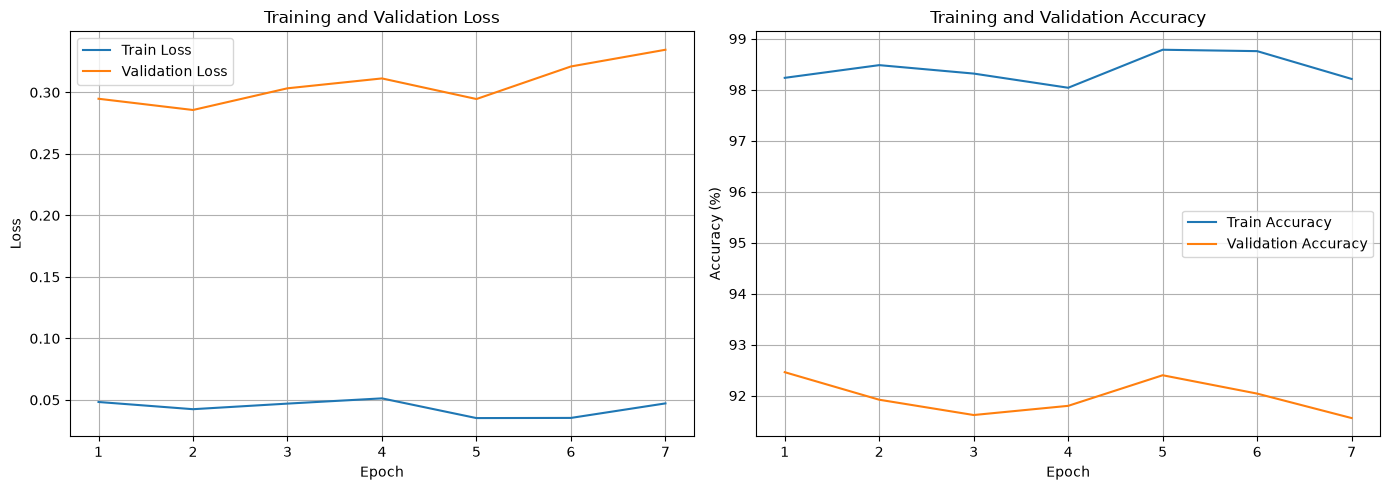

In [37]:
# 方式二：使用 Trainer 训练器训练（推荐，含早停/最优保存/TensorBoard/绘图）
print(f"\n========== 开始训练 (epochs={num_epochs}) ==========")
trainer = Trainer(  # 实例化训练器
    model=model,  # 待训练的 CNN 模型
    trainloader=train_loader,  # 训练集加载器
    valloader=val_loader,  # 验证集加载器
    criterion=criterion,  # 损失函数
    optimizer=optimizer,  # 优化器
    device=device,  # 训练设备
    epochs=num_epochs,  # 训练轮数（CNN 用 20 轮，比全连接版更多）
    early_stopping=True,  # 启用早停
    patience=5,  # 连续 5 轮无提升则停止
    save_path="best_model_cnn.pth",  # 最优权重保存路径（带 cnn 后缀以区分）
    early_stop_mode="loss",  # 以验证损失作为早停依据
    use_tensorboard=False,  # 启用 TensorBoard
    log_dir='tensorboard_logs'  # 日志目录
)
trainer.train()  # 开始训练（内部自动完成早停与权重保存）
trainer.plot(acc=True)  # 绘制训练/验证的损失与准确率曲线

## 12. 测试集评估

In [38]:
# 使用 Trainer 的 evaluating 方法在测试集上评估最终模型
test_loss, test_acc = trainer.evaluating(test_loader)  # 计算测试损失和准确率
print(f"\n========== 测试集评估结果 ==========")  # 打印分隔标题
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")  # 打印测试结果


========== 测试集评估结果 ==========
Test Loss: 0.3297, Test Accuracy: 91.73%


## 13. SELU 版 CNN 模型定义（带调试打印版）
SELU (Scaled Exponential Linear Unit) = 缩放指数线性单元
公式: SELU(x) = scale * (max(0,x) + min(0, alpha * (exp(x) - 1)))
  其中 scale ≈ 1.0507, alpha ≈ 1.6733（由论文推导出的最优值）
特点:
  - 自归一化 (Self-Normalizing): 在网络权重满足特定条件时，各层输出
    自动保持均值 0、方差 1，无需 BatchNorm
  - 负值区有非零输出，缓解"死神经元"问题（ReLU 负数区输出恒为 0）
  - 配合标准化输入效果最佳（本脚本已对数据做了 Normalize）
  - 与 ReLU 参数量完全相同，仅激活函数不同

In [39]:
class CNNModelSELUDebug(nn.Module):
    """
    CNN 卷积神经网络 —— SELU 激活版本（带 shape 打印，便于理解各层数据流）
    结构与 ReLU 版完全相同，仅将 nn.ReLU() 替换为 nn.SELU()
      Conv→SELU→Conv→SELU→MaxPool (28→14)
      → Conv→SELU→Conv→SELU→MaxPool (14→7)
      → Conv→SELU→Conv→SELU→MaxPool (7→3)
      → Flatten → FC(1152,128) → SELU → FC(128,10)
    """

    def __init__(self):
        super().__init__()  # 调用父类 nn.Module 的构造函数
        # ====== 第一组卷积 + 池化 ======
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # (1,28,28)→(32,28,28)
        self.selu1 = nn.SELU()  # SELU 自归一化激活: 配合标准化输入保持输出分布稳定
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)  # (32,28,28)→(32,28,28)
        self.selu2 = nn.SELU()  # SELU 激活
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # (32,28,28)→(32,14,14)

        # ====== 第二组卷积 + 池化 ======
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (32,14,14)→(64,14,14)
        self.selu3 = nn.SELU()  # SELU 激活
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # (64,14,14)→(64,14,14)
        self.selu4 = nn.SELU()  # SELU 激活
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # (64,14,14)→(64,7,7)

        # ====== 第三组卷积 + 池化 ======
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # (64,7,7)→(128,7,7)
        self.selu5 = nn.SELU()  # SELU 激活
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)  # (128,7,7)→(128,7,7)
        self.selu6 = nn.SELU()  # SELU 激活
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # (128,7,7)→(128,3,3)

        # ====== 全连接分类器 ======
        # 展平后输出尺寸: 128 通道 × 3 高度 × 3 宽度 = 1152 维
        self.fc1 = nn.Linear(128 * 3 * 3, 128)  # 全连接层: 1152 → 128
        self.selu_fc = nn.SELU()  # SELU 激活
        self.fc2 = nn.Linear(128, 10)  # 输出层: 128 → 10（10 个类别 logits）

    def forward(self, x):
        """前向传播（包含调试打印）"""
        # ====== 第一组 ======
        print("Input shape:", x.shape)  # 例如 (4, 1, 28, 28)
        x = self.conv1(x)  # 卷积 → (4, 32, 28, 28)
        print("After conv1:", x.shape)  # (4, 32, 28, 28)
        x = self.selu1(x)  # SELU 激活: 正值放大、负值压缩
        print("After selu1:", x.shape)  # (4, 32, 28, 28)
        x = self.conv2(x)  # 卷积 → (4, 32, 28, 28)
        print("After conv2:", x.shape)  # (4, 32, 28, 28)
        x = self.selu2(x)  # SELU 激活
        print("After selu2:", x.shape)  # (4, 32, 28, 28)
        x = self.pool1(x)  # 最大池化 → (4, 32, 14, 14)
        print("After pool1:", x.shape)  # (4, 32, 14, 14)

        # ====== 第二组 ======
        x = self.conv3(x)  # 卷积 → (4, 64, 14, 14)
        print("After conv3:", x.shape)  # (4, 64, 14, 14)
        x = self.selu3(x)  # SELU 激活
        print("After selu3:", x.shape)  # (4, 64, 14, 14)
        x = self.conv4(x)  # 卷积 → (4, 64, 14, 14)
        print("After conv4:", x.shape)  # (4, 64, 14, 14)
        x = self.selu4(x)  # SELU 激活
        print("After selu4:", x.shape)  # (4, 64, 14, 14)
        x = self.pool2(x)  # 最大池化 → (4, 64, 7, 7)
        print("After pool2:", x.shape)  # (4, 64, 7, 7)

        # ====== 第三组 ======
        x = self.conv5(x)  # 卷积 → (4, 128, 7, 7)
        print("After conv5:", x.shape)  # (4, 128, 7, 7)
        x = self.selu5(x)  # SELU 激活
        print("After selu5:", x.shape)  # (4, 128, 7, 7)
        x = self.conv6(x)  # 卷积 → (4, 128, 7, 7)
        print("After conv6:", x.shape)  # (4, 128, 7, 7)
        x = self.selu6(x)  # SELU 激活
        print("After selu6:", x.shape)  # (4, 128, 7, 7)
        x = self.pool3(x)  # 最大池化 → (4, 128, 3, 3)
        print("After pool3:", x.shape)  # (4, 128, 3, 3)

        # ====== 展平 + 全连接 ======
        # torch.flatten(x, 1): 从第 1 维开始展平（保留 batch 维不变）
        x = torch.flatten(x, 1)  # (4, 128, 3, 3) → (4, 1152)
        print("After flatten:", x.shape)  # (4, 1152)
        x = self.fc1(x)  # 全连接: (4, 1152) → (4, 128)
        print("After fc1:", x.shape)  # (4, 128)
        x = self.selu_fc(x)  # SELU 激活
        print("After selu_fc:", x.shape)  # (4, 128)
        x = self.fc2(x)  # 输出层: (4, 128) → (4, 10)
        print("After fc2 (output):", x.shape)  # (4, 10)
        return x  # 返回 logits


# 用随机数据测试调试版 SELU 模型的数据流
sample_input = torch.randn(4, 1, 28, 28)  # 创建随机输入张量（标准正态分布）
model_selu_debug = CNNModelSELUDebug()  # 实例化调试版 SELU-CNN 模型
output_selu = model_selu_debug(sample_input)  # 前向传播，观察各层 shape 变化
print("SELU 前向计算输出 shape:", output_selu.shape)  # torch.Size([4, 10])

Input shape: torch.Size([4, 1, 28, 28])
After conv1: torch.Size([4, 32, 28, 28])
After selu1: torch.Size([4, 32, 28, 28])
After conv2: torch.Size([4, 32, 28, 28])
After selu2: torch.Size([4, 32, 28, 28])
After pool1: torch.Size([4, 32, 14, 14])
After conv3: torch.Size([4, 64, 14, 14])
After selu3: torch.Size([4, 64, 14, 14])
After conv4: torch.Size([4, 64, 14, 14])
After selu4: torch.Size([4, 64, 14, 14])
After pool2: torch.Size([4, 64, 7, 7])
After conv5: torch.Size([4, 128, 7, 7])
After selu5: torch.Size([4, 128, 7, 7])
After conv6: torch.Size([4, 128, 7, 7])
After selu6: torch.Size([4, 128, 7, 7])
After pool3: torch.Size([4, 128, 3, 3])
After flatten: torch.Size([4, 1152])
After fc1: torch.Size([4, 128])
After selu_fc: torch.Size([4, 128])
After fc2 (output): torch.Size([4, 10])
SELU 前向计算输出 shape: torch.Size([4, 10])


In [40]:
# 用真实 batch 数据测试
for images, labels in train_loader:  # 取一个 batch
    break  # 只取第一个 batch
output_selu = model_selu_debug(images)  # 用真实数据前向传播
print("SELU Logits shape:", output_selu.shape)  # (64, 10)

Input shape: torch.Size([64, 1, 28, 28])
After conv1: torch.Size([64, 32, 28, 28])
After selu1: torch.Size([64, 32, 28, 28])
After conv2: torch.Size([64, 32, 28, 28])
After selu2: torch.Size([64, 32, 28, 28])
After pool1: torch.Size([64, 32, 14, 14])
After conv3: torch.Size([64, 64, 14, 14])
After selu3: torch.Size([64, 64, 14, 14])
After conv4: torch.Size([64, 64, 14, 14])
After selu4: torch.Size([64, 64, 14, 14])
After pool2: torch.Size([64, 64, 7, 7])
After conv5: torch.Size([64, 128, 7, 7])
After selu5: torch.Size([64, 128, 7, 7])
After conv6: torch.Size([64, 128, 7, 7])
After selu6: torch.Size([64, 128, 7, 7])
After pool3: torch.Size([64, 128, 3, 3])
After flatten: torch.Size([64, 1152])
After fc1: torch.Size([64, 128])
After selu_fc: torch.Size([64, 128])
After fc2 (output): torch.Size([64, 10])
SELU Logits shape: torch.Size([64, 10])


## 14. SELU 版模型参数统计

In [41]:
print("\n========== SELU 模型参数统计 ==========")  # 打印分隔标题
# 注意: SELU 与 ReLU 参数量完全相同（激活函数无参数），仅激活行为不同
for name, param in model_selu_debug.named_parameters():  # 遍历所有命名参数
    print(f"Name: {name}, Shape: {param.shape}, Number of params: {param.numel()}")  # 打印参数信息

total_params_selu = sum(p.numel() for p in model_selu_debug.parameters())  # 累加总参数量
print(f"SELU 模型总参数量: {total_params_selu}")  # 约 435,306（与 ReLU 版完全相同）


========== SELU 模型参数统计 ==========
Name: conv1.weight, Shape: torch.Size([32, 1, 3, 3]), Number of params: 288
Name: conv1.bias, Shape: torch.Size([32]), Number of params: 32
Name: conv2.weight, Shape: torch.Size([32, 32, 3, 3]), Number of params: 9216
Name: conv2.bias, Shape: torch.Size([32]), Number of params: 32
Name: conv3.weight, Shape: torch.Size([64, 32, 3, 3]), Number of params: 18432
Name: conv3.bias, Shape: torch.Size([64]), Number of params: 64
Name: conv4.weight, Shape: torch.Size([64, 64, 3, 3]), Number of params: 36864
Name: conv4.bias, Shape: torch.Size([64]), Number of params: 64
Name: conv5.weight, Shape: torch.Size([128, 64, 3, 3]), Number of params: 73728
Name: conv5.bias, Shape: torch.Size([128]), Number of params: 128
Name: conv6.weight, Shape: torch.Size([128, 128, 3, 3]), Number of params: 147456
Name: conv6.bias, Shape: torch.Size([128]), Number of params: 128
Name: fc1.weight, Shape: torch.Size([128, 1152]), Number of params: 147456
Name: fc1.bias, Shape: torch

## 15. 正式 SELU 版 CNN 模型定义（纯推理版，无调试打印）

In [42]:
class CNNModelSELU(nn.Module):
    """
    CNN 卷积神经网络 —— SELU 激活版本（正式版，无调试打印）
    结构: 三组 (Conv→SELU→Conv→SELU→MaxPool) + Flatten + FC→SELU→FC
    输入: (batch, 1, 28, 28) 灰度图
    输出: (batch, 10) 类别 logits
    参数量: 约 435,306（与 ReLU 版完全一致）
    SELU 优势:
      - 自归一化: 在归一化输入下自动保持各层输出分布稳定
      - 无 Dead ReLU 问题: 负值区有非零输出，保留更多信息
      - 训练通常更稳定，收敛可能更快
    SELU 注意事项:
      - 必须配合标准化输入使用（本脚本已做 Normalize）
      - 权重初始化建议使用 LeCun Normal（nn.init 默认 kaiming_normal
        对 SELU 并非最优，但不影响训练，仅收敛速度可能略慢）
    """

    def __init__(self):
        super().__init__()  # 调用父类 nn.Module 的构造函数

        # ====== 第一组卷积 + 池化 (28→14) ======
        # Conv2d(in_channels, out_channels, kernel_size, padding)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # (1, 28, 28) → (32, 28, 28)
        # nn.SELU(): 缩放指数线性单元，自归一化激活函数
        # 公式: SELU(x) = scale * x  if x > 0 else scale * alpha * (exp(x) - 1)
        self.selu1 = nn.SELU()
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)  # (32, 28, 28) → (32, 28, 28)
        self.selu2 = nn.SELU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # (32, 28, 28) → (32, 14, 14)

        # ====== 第二组卷积 + 池化 (14→7) ======
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # (32, 14, 14) → (64, 14, 14)
        self.selu3 = nn.SELU()
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # (64, 14, 14) → (64, 14, 14)
        self.selu4 = nn.SELU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # (64, 14, 14) → (64, 7, 7)

        # ====== 第三组卷积 + 池化 (7→3) ======
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # (64, 7, 7) → (128, 7, 7)
        self.selu5 = nn.SELU()
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)  # (128, 7, 7) → (128, 7, 7)
        self.selu6 = nn.SELU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # (128, 7, 7) → (128, 3, 3)

        # ====== 全连接分类器 ======
        self.fc1 = nn.Linear(128 * 3 * 3, 128)  # (128×3×3=1152) → 128
        self.selu_fc = nn.SELU()  # SELU 激活
        # 输出层: 128 → 10 个类别 logits
        # 注意: 此处没有加 Softmax，因为 CrossEntropyLoss 内部已包含
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        """
        前向传播
        参数:
            x: 输入张量，形状 (batch_size, 1, 28, 28)
        返回:
            logits: 形状 (batch_size, 10)，每个类别的原始分数
        """
        # ====== 第一组: Conv→SELU→Conv→SELU→MaxPool ======
        x = self.conv1(x)  # (batch, 1, 28, 28) → (batch, 32, 28, 28)
        x = self.selu1(x)  # SELU 自归一化激活: 正值放大≈1.05倍，负值指数压缩
        x = self.conv2(x)  # (batch, 32, 28, 28) → (batch, 32, 28, 28)
        x = self.selu2(x)  # SELU 激活
        x = self.pool1(x)  # (batch, 32, 28, 28) → (batch, 32, 14, 14)

        # ====== 第二组: Conv→SELU→Conv→SELU→MaxPool ======
        x = self.conv3(x)  # (batch, 32, 14, 14) → (batch, 64, 14, 14)
        x = self.selu3(x)  # SELU 激活
        x = self.conv4(x)  # (batch, 64, 14, 14) → (batch, 64, 14, 14)
        x = self.selu4(x)  # SELU 激活
        x = self.pool2(x)  # (batch, 64, 14, 14) → (batch, 64, 7, 7)

        # ====== 第三组: Conv→SELU→Conv→SELU→MaxPool ======
        x = self.conv5(x)  # (batch, 64, 7, 7) → (batch, 128, 7, 7)
        x = self.selu5(x)  # SELU 激活
        x = self.conv6(x)  # (batch, 128, 7, 7) → (batch, 128, 7, 7)
        x = self.selu6(x)  # SELU 激活
        x = self.pool3(x)  # (batch, 128, 7, 7) → (batch, 128, 3, 3)

        # ====== 展平 + 全连接 ======
        x = torch.flatten(x, 1)  # (batch, 128, 3, 3) → (batch, 1152)
        x = self.fc1(x)  # 全连接: (batch, 1152) → (batch, 128)
        x = self.selu_fc(x)  # SELU 激活
        x = self.fc2(x)  # 输出层: (batch, 128) → (batch, 10) logits
        return x  # 返回 10 个类别的原始分数


# 实例化正式 SELU 模型
model_selu = CNNModelSELU()  # 创建 SELU-CNN 模型实例

In [43]:
# 用随机数据验证前向传播输出维度
sample_input = torch.randn(4, 1, 28, 28)  # 创建 batch_size=4 的随机输入
output_selu = model_selu(sample_input)  # 前向传播
print("SELU 模型输出 shape:", output_selu.shape)  # 应为 torch.Size([4, 10])

SELU 模型输出 shape: torch.Size([4, 10])


## 16. SELU 版模型训练准备

In [44]:
# SELU 模型移至设备（GPU 或 CPU）
model_selu.to(device)  # 将模型参数迁移到目标设备

CNNModelSELU(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (selu1): SELU()
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (selu2): SELU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (selu3): SELU()
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (selu4): SELU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (selu5): SELU()
  (conv6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (selu6): SELU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (selu_fc): SELU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [45]:
# 损失函数: 交叉熵损失（与 ReLU 版一致）
# SELU 的自归一化特性不影响损失函数选择
criterion_selu = nn.CrossEntropyLoss()  # 多分类交叉熵损失

In [46]:
# 优化器: SGD + Momentum（与 ReLU 版参数一致，便于对比）
# 注意: SELU 论文推荐使用学习率 0.01 配合 SGD，
#       但某些场景下 SELU 对学习率更敏感，可在 0.001~0.01 间调试
optimizer_selu = optim.SGD(
    model_selu.parameters(),  # 需要优化的参数
    lr=0.01,  # 学习率（与 ReLU 版保持一致以公平对比）
    momentum=0.9  # 动量系数
)

## 17. SELU 版模型训练

In [47]:
num_epochs_selu = 20  # 训练轮数: 与 ReLU 版保持一致 20 轮


========== 开始 SELU 模型训练 (epochs=20) ==========
Epoch [1/20], Step [100/860], Loss: 0.5784
Epoch [1/20], Step [200/860], Loss: 0.6908
Epoch [1/20], Step [300/860], Loss: 0.4065
Epoch [1/20], Step [400/860], Loss: 0.3645
Epoch [1/20], Step [500/860], Loss: 0.3058
Epoch [1/20], Step [600/860], Loss: 0.2295
Epoch [1/20], Step [700/860], Loss: 0.2723
Epoch [1/20], Step [800/860], Loss: 0.1666
Epoch [1/20], Loss: 0.4641, Train Loss: 0.2801, Val Loss: 0.3071, Train Acc: 89.81%, Val Acc: 88.84%
[Info] Model improved at epoch 1, saving to best_model_cnn_selu.pth
Epoch [2/20], Step [100/860], Loss: 0.3118
Epoch [2/20], Step [200/860], Loss: 0.1642
Epoch [2/20], Step [300/860], Loss: 0.3400
Epoch [2/20], Step [400/860], Loss: 0.1983
Epoch [2/20], Step [500/860], Loss: 0.4870
Epoch [2/20], Step [600/860], Loss: 0.2625
Epoch [2/20], Step [700/860], Loss: 0.2454
Epoch [2/20], Step [800/860], Loss: 0.2179
Epoch [2/20], Loss: 0.2786, Train Loss: 0.2562, Val Loss: 0.3045, Train Acc: 90.28%, Val Acc: 8

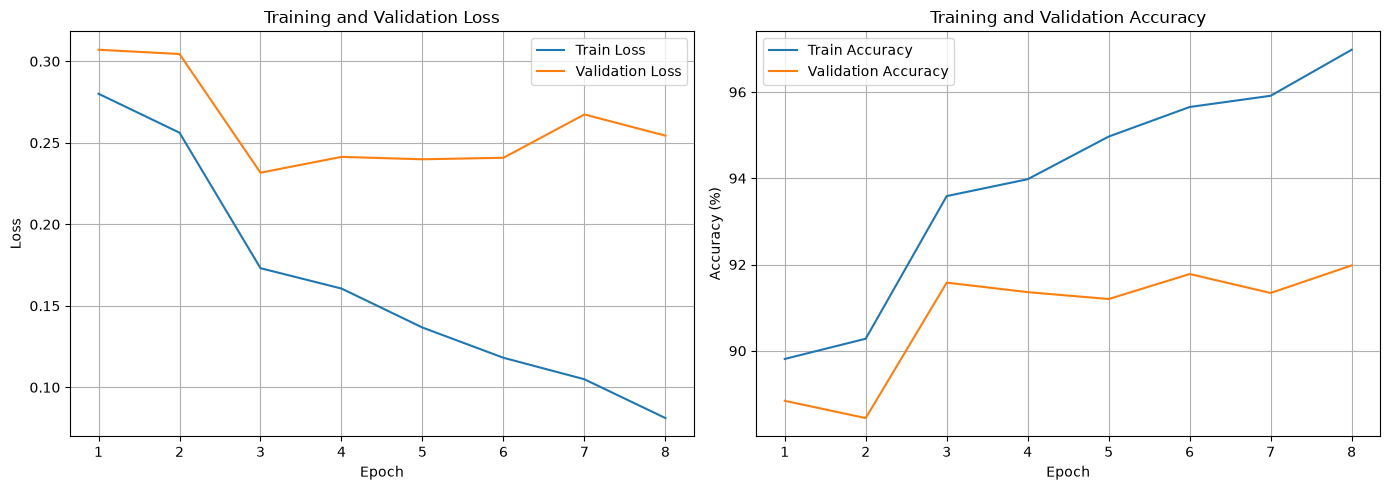

In [48]:
# 使用 Trainer 训练器训练 SELU 模型
print(f"\n========== 开始 SELU 模型训练 (epochs={num_epochs_selu}) ==========")
trainer_selu = Trainer(  # 实例化训练器
    model=model_selu,  # 待训练的 SELU-CNN 模型
    trainloader=train_loader,  # 训练集加载器
    valloader=val_loader,  # 验证集加载器
    criterion=criterion_selu,  # 损失函数
    optimizer=optimizer_selu,  # 优化器
    device=device,  # 训练设备
    epochs=num_epochs_selu,  # 训练轮数
    early_stopping=True,  # 启用早停
    patience=5,  # 连续 5 轮无提升则停止
    save_path="best_model_cnn_selu.pth",  # 最优权重保存路径（带 selu 后缀以区分）
    early_stop_mode="loss",  # 以验证损失作为早停依据
    use_tensorboard=True,  # 启用 TensorBoard
    log_dir='tensorboard_logs_selu'  # SELU 日志使用独立目录，避免与 ReLU 混淆
)
trainer_selu.train()  # 开始训练（内部自动完成早停与权重保存）
trainer_selu.plot(acc=True)  # 绘制 SELU 模型训练曲线

## 18. SELU 版测试集评估

In [49]:
# 使用 Trainer 的 evaluating 方法在测试集上评估 SELU 模型
test_loss_selu, test_acc_selu = trainer_selu.evaluating(test_loader)  # 计算测试损失和准确率
print(f"\n========== SELU 模型测试集评估结果 ==========")  # 打印分隔标题
print(f"SELU Test Loss: {test_loss_selu:.4f}, Test Accuracy: {test_acc_selu:.2f}%")  # 打印 SELU 测试结果


========== SELU 模型测试集评估结果 ==========
SELU Test Loss: 0.2417, Test Accuracy: 90.87%


## 19. ReLU vs SELU 对比总结

In [50]:
print("\n========== ReLU vs SELU 模型对比 ==========")  # 打印对比标题
print(f"ReLU 模型 - Test Accuracy: {test_acc:.2f}%")  # ReLU 版测试准确率
print(f"SELU 模型 - Test Accuracy: {test_acc_selu:.2f}%")  # SELU 版测试准确率
print(f"准确率差异: {test_acc_selu - test_acc:.2f}%")  # 打印两者差异
print("参数量对比: 两者完全相同 (435,306 参数)")  # 激活函数无额外参数
print("激活函数区别:")  # 说明核心差异
print("  ReLU: f(x)=max(0,x) — 简单高效，负数区梯度为 0")
print("  SELU: f(x)=scale*x (x>0) | scale*alpha*(exp(x)-1) (x<=0) — 自归一化")
print("SELU 适用场景:")
print("  - 数据已标准化（本脚本满足）")
print("  - 深层全连接网络（自归一化优势最明显）")
print("  - 希望避免 BatchNorm 的场景")


========== ReLU vs SELU 模型对比 ==========
ReLU 模型 - Test Accuracy: 91.73%
SELU 模型 - Test Accuracy: 90.87%
准确率差异: -0.86%
参数量对比: 两者完全相同 (435,306 参数)
激活函数区别:
  ReLU: f(x)=max(0,x) — 简单高效，负数区梯度为 0
  SELU: f(x)=scale*x (x>0) | scale*alpha*(exp(x)-1) (x<=0) — 自归一化
SELU 适用场景:
  - 数据已标准化（本脚本满足）
  - 深层全连接网络（自归一化优势最明显）
  - 希望避免 BatchNorm 的场景


## 20. 深度可分离卷积 (Depthwise Separable Convolution) 模块定义
深度可分离卷积将标准卷积拆分为两步：
  第1步（深度卷积 Depthwise）: 每个输入通道独立做卷积，groups=in_channels
  第2步（逐点卷积 Pointwise）: 用 1×1 卷积混合各通道信息
优势：大幅减少参数量和计算量
  标准卷积参数量 = in_channels × out_channels × kernel_size²
  深度可分离卷积参数量 = in_channels × kernel_size² + in_channels × out_channels
  当 out_channels 较大时（如 64→128），参数量可减少约 80%~90%

In [51]:
class DepthwiseSeparableConv(nn.Module):
    """
    深度可分离卷积层：先逐通道做深度卷积，再用 1×1 逐点卷积混合通道
    参数量 = in_C × K² + in_C × out_C （远小于标准卷积的 in_C × out_C × K²）

    参数:
        in_channels:  输入特征图的通道数
        out_channels: 输出特征图的通道数
        kernel_size:  深度卷积的卷积核尺寸（逐点卷积固定为 1×1）
        stride:       卷积步长，默认 1
        padding:      边缘填充像素数，默认 0
        bias:         是否使用偏置项，默认 True
    """

    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        """初始化深度可分离卷积：深度卷积 + 逐点卷积"""
        super().__init__()  # 调用父类 nn.Module 的构造函数，完成模块注册

        # ---- 深度卷积 (Depthwise Convolution) ----
        # groups=in_channels 表示每个输入通道独立卷积，互不干扰
        # 输入 in_channels 个通道 → 输出 in_channels 个通道（一一对应）
        # 参数量: in_channels × 1 × kernel_size × kernel_size（每个通道一个卷积核）
        self.depthwise = nn.Conv2d(
            in_channels,  # 输入通道数
            in_channels,  # 输出通道数（深度卷积不改变通道数）
            kernel_size=kernel_size,  # 卷积核尺寸，如 3 表示 3×3
            stride=stride,  # 卷积步长
            padding=padding,  # 边缘填充，padding=1 使空间尺寸不变
            groups=in_channels,  # 分组数=输入通道数，实现逐通道独立卷积
            bias=bias  # 是否使用偏置
        )

        # ---- 逐点卷积 (Pointwise Convolution) ----
        # 1×1 卷积：在每个像素位置对 in_channels 个通道做线性组合
        # 输入 in_channels 个通道 → 输出 out_channels 个通道
        # 参数量: in_channels × out_channels × 1 × 1
        self.pointwise = nn.Conv2d(
            in_channels,  # 输入通道数（深度卷积输出）
            out_channels,  # 输出通道数（目标通道数）
            kernel_size=1,  # 1×1 卷积核，逐点操作不改变空间尺寸
            bias=bias  # 是否使用偏置
        )

    def forward(self, x):
        """
        前向传播：先深度卷积 → 再逐点卷积

        参数:
            x: 输入张量，形状 (batch_size, in_channels, H, W)
        返回:
            输出张量，形状 (batch_size, out_channels, H', W')
        """
        x = self.depthwise(x)  # 第1步: 深度卷积，逐通道提取空间特征
        x = self.pointwise(x)  # 第2步: 逐点卷积，1×1 混合通道信息
        return x  # 返回最终输出特征图

## 21. 深度可分离卷积版 CNN 模型（带调试打印）
结构与标准 CNN 相同，但将 conv2~conv6 的普通卷积替换为深度可分离卷积
参数量: 约 184,554（仅为标准 CNN 的 ~42%，减少约 58%）

In [52]:
class CNNModelSeparableDebug(nn.Module):
    """
    CNN 卷积神经网络 —— 深度可分离卷积版本（带 shape 打印，便于理解数据流）
    结构: Conv(标准) → ReLU → SepConv → ReLU → MaxPool (28→14)
          → SepConv → ReLU → SepConv → ReLU → MaxPool (14→7)
          → SepConv → ReLU → SepConv → ReLU → MaxPool (7→3)
          → Flatten → FC(1152,128) → ReLU → FC(128,10)
    注意: 第一层 conv1 仍用标准卷积（1→32 通道差异大，深度可分离优势不明显）
    """

    def __init__(self):
        """构建深度可分离卷积版 CNN 模型"""
        super().__init__()  # 调用父类 nn.Module 的构造函数

        # ====== 第一组卷积 + 池化 ======
        # 第一层仍用标准卷积: 输入 1 通道（灰度图），输出 32 通道
        # 此处不用深度可分离卷积，因为 in=1 时 depthwise 无法提取多通道特征
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # (1,28,28)→(32,28,28)
        self.relu1 = nn.ReLU()  # ReLU 激活: f(x)=max(0,x)
        # depthwise(32→32, 3×3) + pointwise(32→32, 1×1)
        self.conv2 = DepthwiseSeparableConv(32, 32, kernel_size=3, padding=1)  # (32,28,28)→(32,28,28)
        self.relu2 = nn.ReLU()  # ReLU 激活
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 最大池化: (32,28,28)→(32,14,14)

        # ====== 第二组卷积 + 池化 ======
        # depthwise(32→64, 3×3) + pointwise(32→64, 1×1)
        self.conv3 = DepthwiseSeparableConv(32, 64, kernel_size=3, padding=1)  # (32,14,14)→(64,14,14)
        self.relu3 = nn.ReLU()  # ReLU 激活
        # depthwise(64→64, 3×3) + pointwise(64→64, 1×1)
        self.conv4 = DepthwiseSeparableConv(64, 64, kernel_size=3, padding=1)  # (64,14,14)→(64,14,14)
        self.relu4 = nn.ReLU()  # ReLU 激活
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 最大池化: (64,14,14)→(64,7,7)

        # ====== 第三组卷积 + 池化 ======
        # depthwise(64→128, 3×3) + pointwise(64→128, 1×1)
        self.conv5 = DepthwiseSeparableConv(64, 128, kernel_size=3, padding=1)  # (64,7,7)→(128,7,7)
        self.relu5 = nn.ReLU()  # ReLU 激活
        # depthwise(128→128, 3×3) + pointwise(128→128, 1×1)
        self.conv6 = DepthwiseSeparableConv(128, 128, kernel_size=3, padding=1)  # (128,7,7)→(128,7,7)
        self.relu6 = nn.ReLU()  # ReLU 激活
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # 最大池化: (128,7,7)→(128,3,3)

        # ====== 全连接分类器 ======
        # 展平后尺寸: 128 通道 × 3 × 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 128)  # 全连接层: 1152 → 128
        self.relu_fc = nn.ReLU()  # ReLU 激活
        self.fc2 = nn.Linear(128, 10)  # 输出层: 128 → 10（10 个类别 logits）

    def forward(self, x):
        """前向传播（包含调试打印，输出每层 shape）"""
        # ====== 第一组: Conv→ReLU→SepConv→ReLU→MaxPool ======
        print("Input shape:", x.shape)  # 输入 shape，例如 (4, 1, 28, 28)
        x = self.conv1(x)  # 标准卷积 → (4, 32, 28, 28)
        print("After conv1 (standard):", x.shape)  # (4, 32, 28, 28)
        x = self.relu1(x)  # ReLU 激活
        print("After relu1:", x.shape)  # (4, 32, 28, 28)
        x = self.conv2(x)  # 深度可分离卷积 → (4, 32, 28, 28)
        print("After conv2 (separable):", x.shape)  # (4, 32, 28, 28)
        x = self.relu2(x)  # ReLU 激活
        print("After relu2:", x.shape)  # (4, 32, 28, 28)
        x = self.pool1(x)  # 最大池化 → (4, 32, 14, 14)
        print("After pool1:", x.shape)  # (4, 32, 14, 14)

        # ====== 第二组: SepConv→ReLU→SepConv→ReLU→MaxPool ======
        x = self.conv3(x)  # 深度可分离卷积 → (4, 64, 14, 14)
        print("After conv3 (separable):", x.shape)  # (4, 64, 14, 14)
        x = self.relu3(x)  # ReLU 激活
        print("After relu3:", x.shape)  # (4, 64, 14, 14)
        x = self.conv4(x)  # 深度可分离卷积 → (4, 64, 14, 14)
        print("After conv4 (separable):", x.shape)  # (4, 64, 14, 14)
        x = self.relu4(x)  # ReLU 激活
        print("After relu4:", x.shape)  # (4, 64, 14, 14)
        x = self.pool2(x)  # 最大池化 → (4, 64, 7, 7)
        print("After pool2:", x.shape)  # (4, 64, 7, 7)

        # ====== 第三组: SepConv→ReLU→SepConv→ReLU→MaxPool ======
        x = self.conv5(x)  # 深度可分离卷积 → (4, 128, 7, 7)
        print("After conv5 (separable):", x.shape)  # (4, 128, 7, 7)
        x = self.relu5(x)  # ReLU 激活
        print("After relu5:", x.shape)  # (4, 128, 7, 7)
        x = self.conv6(x)  # 深度可分离卷积 → (4, 128, 7, 7)
        print("After conv6 (separable):", x.shape)  # (4, 128, 7, 7)
        x = self.relu6(x)  # ReLU 激活
        print("After relu6:", x.shape)  # (4, 128, 7, 7)
        x = self.pool3(x)  # 最大池化 → (4, 128, 3, 3)
        print("After pool3:", x.shape)  # (4, 128, 3, 3)

        # ====== 展平 + 全连接 ======
        x = torch.flatten(x, 1)  # 展平: 保留 batch 维度，(4,128,3,3)→(4,1152)
        print("After flatten:", x.shape)  # (4, 1152)
        x = self.fc1(x)  # 全连接: (4, 1152) → (4, 128)
        print("After fc1:", x.shape)  # (4, 128)
        x = self.relu_fc(x)  # ReLU 激活
        print("After relu_fc:", x.shape)  # (4, 128)
        x = self.fc2(x)  # 输出层: (4, 128) → (4, 10) logits
        print("After fc2 (output):", x.shape)  # (4, 10)
        return x  # 返回 10 个类别的原始分数


# 用随机数据测试调试版深度可分离卷积模型的数据流
sample_input = torch.randn(4, 1, 28, 28)  # 创建 batch_size=4 的单通道 28×28 随机输入
model_separable_debug = CNNModelSeparableDebug()  # 实例化调试版模型
output_separable = model_separable_debug(sample_input)  # 前向传播，观察各层 shape 变化
print("深度可分离 CNN 前向计算输出 shape:", output_separable.shape)  # torch.Size([4, 10])

Input shape: torch.Size([4, 1, 28, 28])
After conv1 (standard): torch.Size([4, 32, 28, 28])
After relu1: torch.Size([4, 32, 28, 28])
After conv2 (separable): torch.Size([4, 32, 28, 28])
After relu2: torch.Size([4, 32, 28, 28])
After pool1: torch.Size([4, 32, 14, 14])
After conv3 (separable): torch.Size([4, 64, 14, 14])
After relu3: torch.Size([4, 64, 14, 14])
After conv4 (separable): torch.Size([4, 64, 14, 14])
After relu4: torch.Size([4, 64, 14, 14])
After pool2: torch.Size([4, 64, 7, 7])
After conv5 (separable): torch.Size([4, 128, 7, 7])
After relu5: torch.Size([4, 128, 7, 7])
After conv6 (separable): torch.Size([4, 128, 7, 7])
After relu6: torch.Size([4, 128, 7, 7])
After pool3: torch.Size([4, 128, 3, 3])
After flatten: torch.Size([4, 1152])
After fc1: torch.Size([4, 128])
After relu_fc: torch.Size([4, 128])
After fc2 (output): torch.Size([4, 10])
深度可分离 CNN 前向计算输出 shape: torch.Size([4, 10])


In [53]:
# 用真实 batch 数据测试数据流
for images, labels in train_loader:  # 取训练集第一个 batch
    break  # 只取第一个 batch，跳出循环
output_separable = model_separable_debug(images)  # 用真实 64 张图片前向传播
print("深度可分离 CNN Logits shape:", output_separable.shape)  # (64, 10)

Input shape: torch.Size([64, 1, 28, 28])
After conv1 (standard): torch.Size([64, 32, 28, 28])
After relu1: torch.Size([64, 32, 28, 28])
After conv2 (separable): torch.Size([64, 32, 28, 28])
After relu2: torch.Size([64, 32, 28, 28])
After pool1: torch.Size([64, 32, 14, 14])
After conv3 (separable): torch.Size([64, 64, 14, 14])
After relu3: torch.Size([64, 64, 14, 14])
After conv4 (separable): torch.Size([64, 64, 14, 14])
After relu4: torch.Size([64, 64, 14, 14])
After pool2: torch.Size([64, 64, 7, 7])
After conv5 (separable): torch.Size([64, 128, 7, 7])
After relu5: torch.Size([64, 128, 7, 7])
After conv6 (separable): torch.Size([64, 128, 7, 7])
After relu6: torch.Size([64, 128, 7, 7])
After pool3: torch.Size([64, 128, 3, 3])
After flatten: torch.Size([64, 1152])
After fc1: torch.Size([64, 128])
After relu_fc: torch.Size([64, 128])
After fc2 (output): torch.Size([64, 10])
深度可分离 CNN Logits shape: torch.Size([64, 10])


## 22. 深度可分离卷积模型参数统计

In [54]:
print("\n========== 深度可分离卷积模型参数统计 ==========")  # 打印分隔标题
print("各层参数量明细:")  # 打印说明文字
total_params_separable = 0  # 初始化总参数量累加器

for name, param in model_separable_debug.named_parameters():  # 遍历模型所有命名参数
    num_params = param.numel()  # .numel() 返回张量元素总数 (number of elements)
    print(f"  {name}: {num_params}")  # 打印每层参数名及其参数量
    total_params_separable += num_params  # 累加到总参数量

print(f"\n深度可分离 CNN 模型总参数量: {total_params_separable}")  # 约 184,554
print(f"标准 CNN 模型总参数量: {total_params}")  # 约 435,306（之前统计的）
# 计算参数量减少比例: (1 - 184554/435306) × 100%
print(f"参数量减少: {(1 - total_params_separable / total_params) * 100:.1f}%")  # 约 57.6%


========== 深度可分离卷积模型参数统计 ==========
各层参数量明细:
  conv1.weight: 288
  conv1.bias: 32
  conv2.depthwise.weight: 288
  conv2.depthwise.bias: 32
  conv2.pointwise.weight: 1024
  conv2.pointwise.bias: 32
  conv3.depthwise.weight: 288
  conv3.depthwise.bias: 32
  conv3.pointwise.weight: 2048
  conv3.pointwise.bias: 64
  conv4.depthwise.weight: 576
  conv4.depthwise.bias: 64
  conv4.pointwise.weight: 4096
  conv4.pointwise.bias: 64
  conv5.depthwise.weight: 576
  conv5.depthwise.bias: 64
  conv5.pointwise.weight: 8192
  conv5.pointwise.bias: 128
  conv6.depthwise.weight: 1152
  conv6.depthwise.bias: 128
  conv6.pointwise.weight: 16384
  conv6.pointwise.bias: 128
  fc1.weight: 147456
  fc1.bias: 128
  fc2.weight: 1280
  fc2.bias: 10

深度可分离 CNN 模型总参数量: 184554
标准 CNN 模型总参数量: 435306
参数量减少: 57.6%


In [55]:
# 手动验证各组件的参数量，加深理解
print("\n--- 参数量对比分析 ---")  # 打印分析标题
# 标准卷积 conv2: 32×32×3×3 + 32 = 9,216 + 32 = 9,248
print(f"标准 conv2 (32→32) 参数量: {32 * 32 * 3 * 3 + 32}")  # 9248
# 深度可分离 conv2: depthwise(32×1×3×3+32) + pointwise(32×32×1×1+32) = 288+32 + 1024+32 = 1376
sep_conv2_params = (32 * 1 * 3 * 3 + 32) + (32 * 32 * 1 * 1 + 32)  # 深度+逐点
print(f"可分离 conv2 (32→32) 参数量: {sep_conv2_params}")  # 1376
print(f"conv2 参数减少比例: {(1 - sep_conv2_params / (32 * 32 * 3 * 3 + 32)) * 100:.1f}%")  # 约 85%

# 标准卷积 conv5: 64×128×3×3 + 128 = 73,728 + 128 = 73,856
print(f"标准 conv5 (64→128) 参数量: {64 * 128 * 3 * 3 + 128}")  # 73856
# 深度可分离 conv5: depthwise(64×1×3×3+64) + pointwise(64×128×1×1+128) = 576+64 + 8192+128 = 8960
sep_conv5_params = (64 * 1 * 3 * 3 + 64) + (64 * 128 * 1 * 1 + 128)  # 深度+逐点
print(f"可分离 conv5 (64→128) 参数量: {sep_conv5_params}")  # 8960
print(f"conv5 参数减少比例: {(1 - sep_conv5_params / (64 * 128 * 3 * 3 + 128)) * 100:.1f}%")  # 约 87.9%


--- 参数量对比分析 ---
标准 conv2 (32→32) 参数量: 9248
可分离 conv2 (32→32) 参数量: 1376
conv2 参数减少比例: 85.1%
标准 conv5 (64→128) 参数量: 73856
可分离 conv5 (64→128) 参数量: 8960
conv5 参数减少比例: 87.9%


## 23. 正式深度可分离卷积版 CNN 模型（纯推理版，无调试打印）

In [56]:
class CNNModelSeparable(nn.Module):
    """
    CNN 卷积神经网络 —— 深度可分离卷积版本（正式版，无调试打印）

    结构: 三组卷积块（第一层标准卷积 + 其余深度可分离卷积）+ Flatten + FC→ReLU→FC
    输入: (batch, 1, 28, 28) 灰度图
    输出: (batch, 10) 类别 logits

    参数量: 约 184,554（标准 CNN 约 435,306，减少约 57.6%）

    深度可分离卷积的优势:
      - 参数量大幅减少: 将空间卷积与通道混合解耦
      - 计算量 (FLOPs) 显著降低: 适合移动端/嵌入式部署
      - 正则化效果: 参数少意味着过拟合风险降低

    深度可分离卷积的注意事项:
      - 第一层仍用标准卷积: 输入仅 1 通道时 depthwise 无法提取有价值特征
      - 在通道数较小的层（如 32→32），压缩效果不如通道数大的层明显
      - 训练可能需要稍多的 epoch 才能达到与标准 CNN 相当的性能
    """

    def __init__(self):
        """构建深度可分离卷积版 CNN 模型（正式版）"""
        super().__init__()  # 调用父类 nn.Module 的构造函数

        # ====== 第一组卷积 + 池化 (28→14) ======
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 第一层标准卷积: (1,28,28)→(32,28,28)
        self.relu1 = nn.ReLU()  # ReLU 激活: 保留正值、抑制负值，引入非线性
        # 深度可分离卷积: depthwise(32→32,3×3) + pointwise(32→32,1×1)
        self.conv2 = DepthwiseSeparableConv(32, 32, kernel_size=3, padding=1)  # (32,28,28)→(32,28,28)
        self.relu2 = nn.ReLU()  # ReLU 激活
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 最大池化降采样: (32,28,28)→(32,14,14)

        # ====== 第二组卷积 + 池化 (14→7) ======
        # 深度可分离卷积: depthwise(32→64,3×3) + pointwise(32→64,1×1)
        self.conv3 = DepthwiseSeparableConv(32, 64, kernel_size=3, padding=1)  # (32,14,14)→(64,14,14)
        self.relu3 = nn.ReLU()  # ReLU 激活
        # 深度可分离卷积: depthwise(64→64,3×3) + pointwise(64→64,1×1)
        self.conv4 = DepthwiseSeparableConv(64, 64, kernel_size=3, padding=1)  # (64,14,14)→(64,14,14)
        self.relu4 = nn.ReLU()  # ReLU 激活
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 最大池化降采样: (64,14,14)→(64,7,7)

        # ====== 第三组卷积 + 池化 (7→3) ======
        # 深度可分离卷积: depthwise(64→128,3×3) + pointwise(64→128,1×1)
        self.conv5 = DepthwiseSeparableConv(64, 128, kernel_size=3, padding=1)  # (64,7,7)→(128,7,7)
        self.relu5 = nn.ReLU()  # ReLU 激活
        # 深度可分离卷积: depthwise(128→128,3×3) + pointwise(128→128,1×1)
        self.conv6 = DepthwiseSeparableConv(128, 128, kernel_size=3, padding=1)  # (128,7,7)→(128,7,7)
        self.relu6 = nn.ReLU()  # ReLU 激活
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # 最大池化降采样: (128,7,7)→(128,3,3)

        # ====== 全连接分类器 ======
        # 展平后尺寸: 128 通道 × 3 高度 × 3 宽度 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 128)  # 全连接层: 1152 → 128
        self.relu_fc = nn.ReLU()  # ReLU 激活
        self.fc2 = nn.Linear(128, 10)  # 输出层: 128 → 10 logits（不加 Softmax，CrossEntropyLoss 内置）

    def forward(self, x):
        """
        前向传播

        参数:
            x: 输入张量，形状 (batch_size, 1, 28, 28)
        返回:
            logits: 形状 (batch_size, 10)，每个类别的原始分数
        """
        # ====== 第一组: Conv→ReLU→SepConv→ReLU→MaxPool ======
        x = self.conv1(x)  # 标准卷积: (batch, 1, 28, 28) → (batch, 32, 28, 28)
        x = self.relu1(x)  # ReLU 非线性激活
        x = self.conv2(x)  # 深度可分离卷积: (batch, 32, 28, 28) → (batch, 32, 28, 28)
        x = self.relu2(x)  # ReLU 非线性激活
        x = self.pool1(x)  # 最大池化降采样: (batch, 32, 28, 28) → (batch, 32, 14, 14)

        # ====== 第二组: SepConv→ReLU→SepConv→ReLU→MaxPool ======
        x = self.conv3(x)  # 深度可分离卷积: (batch, 32, 14, 14) → (batch, 64, 14, 14)
        x = self.relu3(x)  # ReLU 非线性激活
        x = self.conv4(x)  # 深度可分离卷积: (batch, 64, 14, 14) → (batch, 64, 14, 14)
        x = self.relu4(x)  # ReLU 非线性激活
        x = self.pool2(x)  # 最大池化降采样: (batch, 64, 14, 14) → (batch, 64, 7, 7)

        # ====== 第三组: SepConv→ReLU→SepConv→ReLU→MaxPool ======
        x = self.conv5(x)  # 深度可分离卷积: (batch, 64, 7, 7) → (batch, 128, 7, 7)
        x = self.relu5(x)  # ReLU 非线性激活
        x = self.conv6(x)  # 深度可分离卷积: (batch, 128, 7, 7) → (batch, 128, 7, 7)
        x = self.relu6(x)  # ReLU 非线性激活
        x = self.pool3(x)  # 最大池化降采样: (batch, 128, 7, 7) → (batch, 128, 3, 3)

        # ====== 展平 + 全连接 ======
        # torch.flatten(x, start_dim=1): 从 dim=1 开始展平，保留 dim=0（batch_size）
        # (batch, 128, 3, 3) → (batch, 128×3×3) = (batch, 1152)
        x = torch.flatten(x, 1)  # 展平特征图为向量
        x = self.fc1(x)  # 全连接: (batch, 1152) → (batch, 128)
        x = self.relu_fc(x)  # ReLU 非线性激活
        x = self.fc2(x)  # 输出层: (batch, 128) → (batch, 10) logits
        return x  # 返回 10 个类别的原始分数（logits）


# 实例化深度可分离卷积 CNN 模型
model_separable = CNNModelSeparable()  # 创建深度可分离 CNN 模型实例

In [57]:
# 用随机数据验证前向传播输出维度是否正确
sample_input = torch.randn(4, 1, 28, 28)  # batch_size=4，单通道 28×28 随机输入
output_separable = model_separable(sample_input)  # 前向传播
print("深度可分离 CNN 输出 shape:", output_separable.shape)  # 应为 torch.Size([4, 10])

深度可分离 CNN 输出 shape: torch.Size([4, 10])


## 24. 深度可分离卷积模型训练准备

In [58]:
# 将深度可分离模型移至设备（GPU 或 CPU）
model_separable.to(device)  # 将模型所有参数迁移到目标设备

CNNModelSeparable(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (conv2): DepthwiseSeparableConv(
    (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
    (pointwise): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  )
  (relu2): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): DepthwiseSeparableConv(
    (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
    (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (relu3): ReLU()
  (conv4): DepthwiseSeparableConv(
    (depthwise): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
    (pointwise): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (relu4): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv5): DepthwiseSeparableConv(
    (depthwise): Conv2d(64

In [59]:
# 损失函数: 交叉熵损失 CrossEntropyLoss（与标准 CNN 一致）
# 内部包含 softmax + NLLLoss，输入 logits 即可
criterion_separable = nn.CrossEntropyLoss()  # 多分类交叉熵损失，默认对 batch 求均值

In [60]:
# 优化器: SGD + Momentum（与标准 CNN 参数一致，便于公平对比）
optimizer_separable = optim.SGD(
    model_separable.parameters(),  # 需要优化的参数（模型所有可学习参数）
    lr=0.01,  # 学习率: 控制参数更新步长，0.01 是常用默认值
    momentum=0.9  # 动量系数: 累积历史梯度方向，加速收敛、减少震荡
)

## 25. 深度可分离卷积模型训练

In [61]:
num_epochs_separable = 20  # 训练轮数: 与标准 CNN 保持一致 20 轮，公平对比


========== 开始深度可分离 CNN 模型训练 (epochs=20) ==========
Epoch [1/20], Step [100/860], Loss: 2.3060
Epoch [1/20], Step [200/860], Loss: 2.3005
Epoch [1/20], Step [300/860], Loss: 2.3007
Epoch [1/20], Step [400/860], Loss: 2.2993
Epoch [1/20], Step [500/860], Loss: 2.2998
Epoch [1/20], Step [600/860], Loss: 2.3042
Epoch [1/20], Step [700/860], Loss: 2.2996
Epoch [1/20], Step [800/860], Loss: 2.3061
Epoch [1/20], Loss: 2.3034, Train Loss: 2.3029, Val Loss: 2.3027, Train Acc: 10.01%, Val Acc: 9.84%
[Info] Model improved at epoch 1, saving to best_model_separable_cnn.pth
Epoch [2/20], Step [100/860], Loss: 2.3040
Epoch [2/20], Step [200/860], Loss: 2.2981
Epoch [2/20], Step [300/860], Loss: 2.3028
Epoch [2/20], Step [400/860], Loss: 2.3013
Epoch [2/20], Step [500/860], Loss: 2.3034
Epoch [2/20], Step [600/860], Loss: 2.3032
Epoch [2/20], Step [700/860], Loss: 2.3067
Epoch [2/20], Step [800/860], Loss: 2.3050
Epoch [2/20], Loss: 2.3030, Train Loss: 2.3029, Val Loss: 2.3040, Train Acc: 10.10%, Va

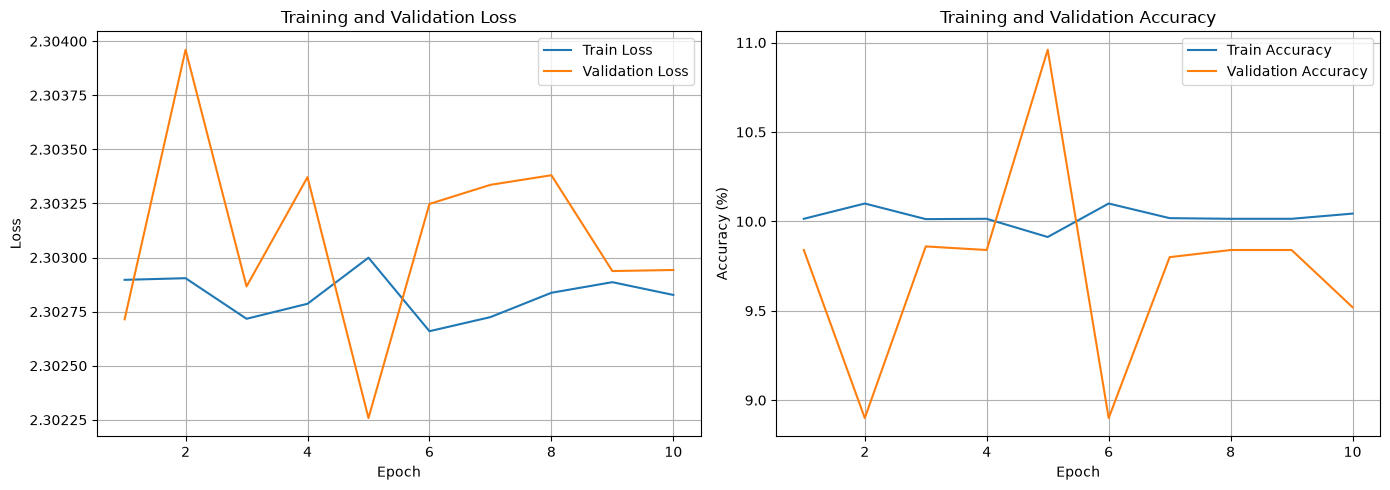

In [62]:
# 使用 Trainer 训练器训练深度可分离模型
print(f"\n========== 开始深度可分离 CNN 模型训练 (epochs={num_epochs_separable}) ==========")
trainer_separable = Trainer(  # 实例化训练器
    model=model_separable,  # 待训练的深度可分离 CNN 模型
    trainloader=train_loader,  # 训练集加载器（与标准 CNN 共用相同数据）
    valloader=val_loader,  # 验证集加载器
    criterion=criterion_separable,  # 损失函数（交叉熵）
    optimizer=optimizer_separable,  # 优化器（SGD + Momentum）
    device=device,  # 训练设备（GPU 或 CPU）
    epochs=num_epochs_separable,  # 训练轮数
    early_stopping=True,  # 启用早停: 验证集表现不再提升时自动停止
    patience=5,  # 早停容忍度: 连续 5 轮无提升则停止训练
    save_path="best_model_separable_cnn.pth",  # 最优权重保存路径（带 separable 后缀以区分）
    early_stop_mode="loss",  # 早停依据: 以验证损失 (val_loss) 作为监控指标
    use_tensorboard=True,  # 启用 TensorBoard 日志记录
    log_dir='tensorboard_logs_separable'  # 深度可分离版独立日志目录，避免与其他版本混淆
)
trainer_separable.train()  # 开始训练（内部自动完成早停判断与最优权重保存）
trainer_separable.plot(acc=True)  # 绘制训练/验证的损失与准确率曲线

## 26. 深度可分离卷积模型测试集评估

In [63]:
# 使用 Trainer 的 evaluating 方法在测试集上评估模型
test_loss_separable, test_acc_separable = trainer_separable.evaluating(test_loader)  # 计算测试损失和准确率
print(f"\n========== 深度可分离 CNN 模型测试集评估结果 ==========")  # 打印分隔标题
print(f"Separable CNN Test Loss: {test_loss_separable:.4f}, Test Accuracy: {test_acc_separable:.2f}%")  # 打印结果


========== 深度可分离 CNN 模型测试集评估结果 ==========
Separable CNN Test Loss: 2.3029, Test Accuracy: 10.00%


## 26.5 深度可分离卷积为什么会训练失败？（10% 准确率分析）

### 现象：不是"准确率低"，而是"完全没学习"

上一节的深度可分离 CNN 测试准确率只有 **10%**，损失卡死在 **2.3026**。这两个数字非常特殊：

- **10%** = 随机瞎猜（FashionMNIST 有 10 类，闭眼猜就是 1/10）。
- **2.3026** = $-\ln(1/10) = \ln(10)$，正好是"模型对 10 个类都输出 1/10 概率"时的交叉熵。

也就是说，网络从头到尾都在输出均匀分布，梯度根本没更新。对比之下，标准 CNN 同样的配置（无 BN、SGD lr=0.01）第 1 轮就学到了 83%。

### 根本原因

深度可分离卷积比普通卷积难训练得多：

1. **参数量锐减**：标准 CNN 约 435K 参数，深度可分离版只有约 184K（42%），表达容量下降。
2. **depthwise 各通道各自为战**：`groups=in_channels` 让每个输出通道只由 1 个输入通道经过 3×3 卷积得到，通道之间在空间卷积阶段完全不通气，梯度流动更弱、更脆弱。
3. **最致命：没有 BatchNorm**。MobileNet 原文在每个 depthwise / pointwise 后面都加了 BN + ReLU，正是因为深度可分离卷积离了 BN 就训不动。而本 notebook 的 `DepthwiseSeparableConv` 没有 BN，ReLU 也只套在 pointwise 之后，结果网络陷入"死 ReLU"——大量激活变成 0、梯度消失，最终只会输出均匀分布（损失恒等于 ln 10）。

### 修复

按照 MobileNet 的标准做法，给 depthwise 和 pointwise 各加一层 BatchNorm，并在其间插入 ReLU。下面的新模型 `CNNModelSeparableBN` 就是修复后的版本。


In [64]:
class DepthwiseSeparableConvBN(nn.Module):
    """带 BatchNorm + ReLU 的深度可分离卷积（MobileNet 标准结构）

    顺序: depthwise → BN → ReLU → pointwise → BN → ReLU
    BatchNorm 把每层输出归一化到均值 0、方差 1，避免深度可分离卷积
    因缺乏归一化而陷入"死 ReLU"、梯度消失，从而解决训练崩溃问题。
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        # 深度卷积: 逐通道独立卷积，groups=in_channels
        # bias=False: 后面紧跟 BatchNorm，偏置会被 BN 抵消，去掉可减少冗余参数
        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=kernel_size, stride=stride, padding=padding,
            groups=in_channels, bias=False
        )
        self.bn1 = nn.BatchNorm2d(in_channels)  # depthwise 之后的归一化
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)  # pointwise 之后的归一化
        self.relu = nn.ReLU()  # 共用 ReLU（两处都接）

    def forward(self, x):
        x = self.relu(self.bn1(self.depthwise(x)))  # depthwise → BN → ReLU
        x = self.relu(self.bn2(self.pointwise(x)))  # pointwise → BN → ReLU
        return x


class CNNModelSeparableBN(nn.Module):
    """深度可分离卷积版 CNN（带 BatchNorm，修复训练崩溃）

    结构与 CNNModelSeparable 完全一致（conv1~conv6 + 3 次池化 + 全连接），
    区别仅在:
      - 每个深度可分离卷积内部加入 BN + ReLU
      - 第一层标准卷积后也加入 BN
    """
    def __init__(self):
        super().__init__()
        # ====== 第一组: 标准卷积 + BN (28→14) ======
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False)  # (1,28,28)→(32,28,28)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.conv2 = DepthwiseSeparableConvBN(32, 32, kernel_size=3, padding=1)  # (32,28,28)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # (32,14,14)

        # ====== 第二组 (14→7) ======
        self.conv3 = DepthwiseSeparableConvBN(32, 64, kernel_size=3, padding=1)  # (64,14,14)
        self.conv4 = DepthwiseSeparableConvBN(64, 64, kernel_size=3, padding=1)  # (64,14,14)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # (64,7,7)

        # ====== 第三组 (7→3) ======
        self.conv5 = DepthwiseSeparableConvBN(64, 128, kernel_size=3, padding=1)  # (128,7,7)
        self.conv6 = DepthwiseSeparableConvBN(128, 128, kernel_size=3, padding=1)  # (128,7,7)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)  # (128,3,3)

        # ====== 全连接分类器 ======
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.relu_fc = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))  # (1,28,28)→(32,28,28)
        x = self.conv2(x)  # (32,28,28)
        x = self.pool1(x)  # (32,14,14)
        x = self.conv3(x)  # (64,14,14)
        x = self.conv4(x)  # (64,14,14)
        x = self.pool2(x)  # (64,7,7)
        x = self.conv5(x)  # (128,7,7)
        x = self.conv6(x)  # (128,7,7)
        x = self.pool3(x)  # (128,3,3)
        x = torch.flatten(x, 1)  # (batch, 1152)
        x = self.relu_fc(self.fc1(x))  # (batch, 128)
        x = self.fc2(x)  # (batch, 10) logits
        return x


In [65]:
# 实例化带 BatchNorm 的深度可分离 CNN 模型
model_separable_bn = CNNModelSeparableBN()  # 创建带 BN 的深度可分离 CNN
model_separable_bn.to(device)  # 将模型参数迁移到 GPU/CPU
total_params_separable_bn = sum(p.numel() for p in model_separable_bn.parameters())  # 统计参数量
print(f"带 BatchNorm 的深度可分离 CNN 参数量: {total_params_separable_bn}")  # 应约 186K


带 BatchNorm 的深度可分离 CNN 参数量: 185322


In [66]:
# 损失函数与优化器（与无 BN 版本一致，保证公平对比）
criterion_separable_bn = nn.CrossEntropyLoss()  # 交叉熵损失
optimizer_separable_bn = optim.SGD(
    model_separable_bn.parameters(),  # 优化模型所有参数（含 BN 的 γ、β）
    lr=0.01,  # 学习率
    momentum=0.9  # 动量
)
num_epochs_separable_bn = 20  # 训练轮数: 与其他版本保持一致



========== 开始带 BatchNorm 的深度可分离 CNN 训练 (epochs=20) ==========
Epoch [1/20], Step [100/860], Loss: 0.5806
Epoch [1/20], Step [200/860], Loss: 0.6262
Epoch [1/20], Step [300/860], Loss: 0.5158
Epoch [1/20], Step [400/860], Loss: 0.2952
Epoch [1/20], Step [500/860], Loss: 0.3810
Epoch [1/20], Step [600/860], Loss: 0.2698
Epoch [1/20], Step [700/860], Loss: 0.2272
Epoch [1/20], Step [800/860], Loss: 0.3128
Epoch [1/20], Loss: 0.4619, Train Loss: 0.3114, Val Loss: 0.3455, Train Acc: 88.51%, Val Acc: 87.08%
[Info] Model improved at epoch 1, saving to best_model_separable_bn_cnn.pth
Epoch [2/20], Step [100/860], Loss: 0.2652
Epoch [2/20], Step [200/860], Loss: 0.2825
Epoch [2/20], Step [300/860], Loss: 0.2014
Epoch [2/20], Step [400/860], Loss: 0.3343
Epoch [2/20], Step [500/860], Loss: 0.2289
Epoch [2/20], Step [600/860], Loss: 0.3739
Epoch [2/20], Step [700/860], Loss: 0.3216
Epoch [2/20], Step [800/860], Loss: 0.2629
Epoch [2/20], Loss: 0.2826, Train Loss: 0.2288, Val Loss: 0.2643, Train 

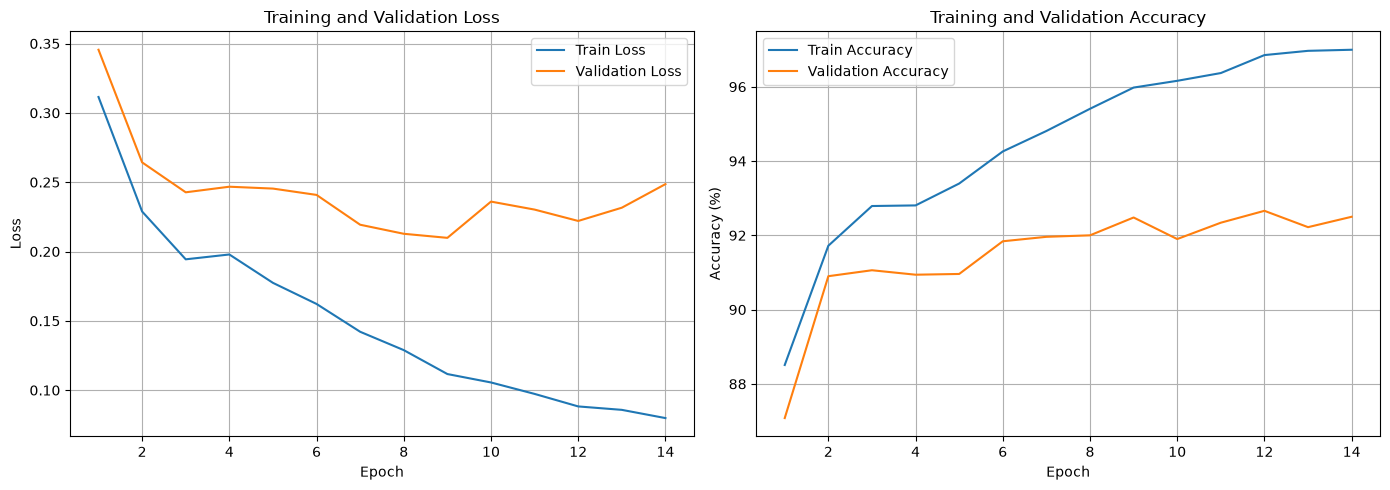

In [67]:
# 使用 Trainer 训练带 BatchNorm 的深度可分离模型
print(f"\n========== 开始带 BatchNorm 的深度可分离 CNN 训练 (epochs={num_epochs_separable_bn}) ==========")
trainer_separable_bn = Trainer(
    model=model_separable_bn,  # 待训练的带 BN 深度可分离 CNN
    trainloader=train_loader,  # 训练集加载器
    valloader=val_loader,  # 验证集加载器
    criterion=criterion_separable_bn,  # 交叉熵损失
    optimizer=optimizer_separable_bn,  # SGD + Momentum
    device=device,  # 训练设备
    epochs=num_epochs_separable_bn,  # 训练轮数
    early_stopping=True,  # 启用早停
    patience=5,  # 连续 5 轮无提升则停止
    save_path="best_model_separable_bn_cnn.pth",  # 最优权重保存路径
    early_stop_mode="loss",  # 以验证损失作为早停依据
    use_tensorboard=True,  # 启用 TensorBoard
    log_dir='tensorboard_logs_separable_bn'  # 独立日志目录
)
trainer_separable_bn.train()  # 开始训练（内部自动完成早停与权重保存）
trainer_separable_bn.plot(acc=True)  # 绘制训练/验证损失与准确率曲线


In [68]:
# 在测试集上评估带 BatchNorm 的深度可分离模型
test_loss_separable_bn, test_acc_separable_bn = trainer_separable_bn.evaluating(test_loader)  # 计算测试损失和准确率
print(f"\n========== 带 BatchNorm 的深度可分离 CNN 测试集评估结果 ==========")  # 打印分隔标题
print(f"Separable-BN CNN Test Loss: {test_loss_separable_bn:.4f}, Test Accuracy: {test_acc_separable_bn:.2f}%")  # 打印结果



========== 带 BatchNorm 的深度可分离 CNN 测试集评估结果 ==========
Separable-BN CNN Test Loss: 0.2319, Test Accuracy: 91.84%


## 27. ReLU vs SELU vs Separable-CNN 三模型对比总结

In [69]:
print("========== 四模型对比总结 ==========")  # 打印对比标题

# 构建对比表格数据: 模型名称、参数量、测试准确率
print(f"{'模型':<25} {'参数量':<12} {'测试准确率':<12}")  # 打印表头
print("-" * 49)  # 打印分隔线
print(f"{'标准 CNN (ReLU)':<25} {total_params:<12} {test_acc:<12.2f}%")  # 标准 CNN: ~435K 参数
print(f"{'标准 CNN (SELU)':<25} {total_params_selu:<12} {test_acc_selu:<12.2f}%")  # SELU CNN: ~435K 参数
print(f"{'深度可分离 CNN':<25} {total_params_separable:<12} {test_acc_separable:<12.2f}%")  # 无 BN 可分离 CNN: ~185K 参数
print(f"{'深度可分离 CNN (BN)':<25} {total_params_separable_bn:<12} {test_acc_separable_bn:<12.2f}%")  # 带 BN 可分离 CNN
print("-" * 49)  # 打印分隔线

# 打印对比分析结论
print("\n结论分析:")  # 打印标题
print(f"  1. 深度可分离 CNN 参数量仅为标准 CNN 的 {total_params_separable / total_params * 100:.1f}%")  # 约 42%
print(f"  2. 参数减少约 {(1 - total_params_separable / total_params) * 100:.1f}%，适合移动端/嵌入式部署")  # 约 58%
print(f"  3. 无 BN 的深度可分离 CNN 训练崩溃（10% ≈ 随机），因缺乏 BatchNorm 导致梯度消失")
print(f"  4. 加入 BatchNorm 后，深度可分离 CNN 以约 42% 的参数恢复了正常准确率，性价比更高")
print("  5. 深度可分离卷积核心思想: 将空间特征提取(深度卷积)与通道混合(逐点卷积)解耦")


========== 四模型对比总结 ==========
模型                        参数量          测试准确率       
-------------------------------------------------
标准 CNN (ReLU)             435306       91.73       %
标准 CNN (SELU)             435306       90.87       %
深度可分离 CNN                 184554       10.00       %
深度可分离 CNN (BN)            185322       91.84       %
-------------------------------------------------

结论分析:
  1. 深度可分离 CNN 参数量仅为标准 CNN 的 42.4%
  2. 参数减少约 57.6%，适合移动端/嵌入式部署
  3. 无 BN 的深度可分离 CNN 训练崩溃（10% ≈ 随机），因缺乏 BatchNorm 导致梯度消失
  4. 加入 BatchNorm 后，深度可分离 CNN 以约 42% 的参数恢复了正常准确率，性价比更高
  5. 深度可分离卷积核心思想: 将空间特征提取(深度卷积)与通道混合(逐点卷积)解耦
